In [1]:
# Neonatal Event Detection
# PICS Database

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

from scipy.signal import butter, filtfilt, find_peaks

print("Libraries imported successfully.")

# PICS database settings
PICS_PATH = "https://physionet.org/files/picsdb/1.0.0/"
INFANT = 1

print("Selected infant:", INFANT)
print("PICS database path:", PICS_PATH)

Libraries imported successfully.
Selected infant: 1
PICS database path: https://physionet.org/files/picsdb/1.0.0/


In [2]:
# Load only the first 60 seconds of Infant 1 ECG and respiration

ECG_FS = 250
RESP_FS = 500

DURATION_SECONDS = 60

ecg_record = wfdb.rdrecord(
    "infant1_ecg",
    pn_dir="picsdb/1.0.0",
    sampfrom=0,
    sampto=ECG_FS * DURATION_SECONDS
)

resp_record = wfdb.rdrecord(
    "infant1_resp",
    pn_dir="picsdb/1.0.0",
    sampfrom=0,
    sampto=RESP_FS * DURATION_SECONDS
)

print("ECG loaded successfully.")
print("ECG sampling frequency:", ecg_record.fs)
print("ECG samples:", ecg_record.sig_len)
print("ECG duration (seconds):", ecg_record.sig_len / ecg_record.fs)

print("\nRespiration loaded successfully.")
print("Respiration sampling frequency:", resp_record.fs)
print("Respiration samples:", resp_record.sig_len)
print("Respiration duration (seconds):", resp_record.sig_len / resp_record.fs)

ECG loaded successfully.
ECG sampling frequency: 250
ECG samples: 15000
ECG duration (seconds): 60.0

Respiration loaded successfully.
Respiration sampling frequency: 500
Respiration samples: 30000
Respiration duration (seconds): 60.0


In [3]:
# Extract the actual signal arrays

ecg = ecg_record.p_signal[:, 0]
respiration = resp_record.p_signal[:, 0]

print("ECG signal shape:", ecg.shape)
print("ECG first 10 samples:", ecg[:10])

print("\nRespiration signal shape:", respiration.shape)
print("Respiration first 10 samples:", respiration[:10])

print("\nECG signal range:", np.min(ecg), "to", np.max(ecg))
print("Respiration signal range:", np.min(respiration), "to", np.max(respiration))

ECG signal shape: (15000,)
ECG first 10 samples: [-0.01998352 -0.01998352 -0.01498764 -0.00499588 -0.00499588 -0.00499588
  0.          0.          0.00499588  0.00499588]

Respiration signal shape: (30000,)
Respiration first 10 samples: [-0.55500755 -0.55500755 -0.5535156  -0.5535156  -0.5535156  -0.55202364
 -0.5535156  -0.5535156  -0.55649951 -0.55500755]

ECG signal range: -0.48085347620218677 to 1.4125851469731772
Respiration signal range: -0.5579914634765867 to 0.48413965213409726


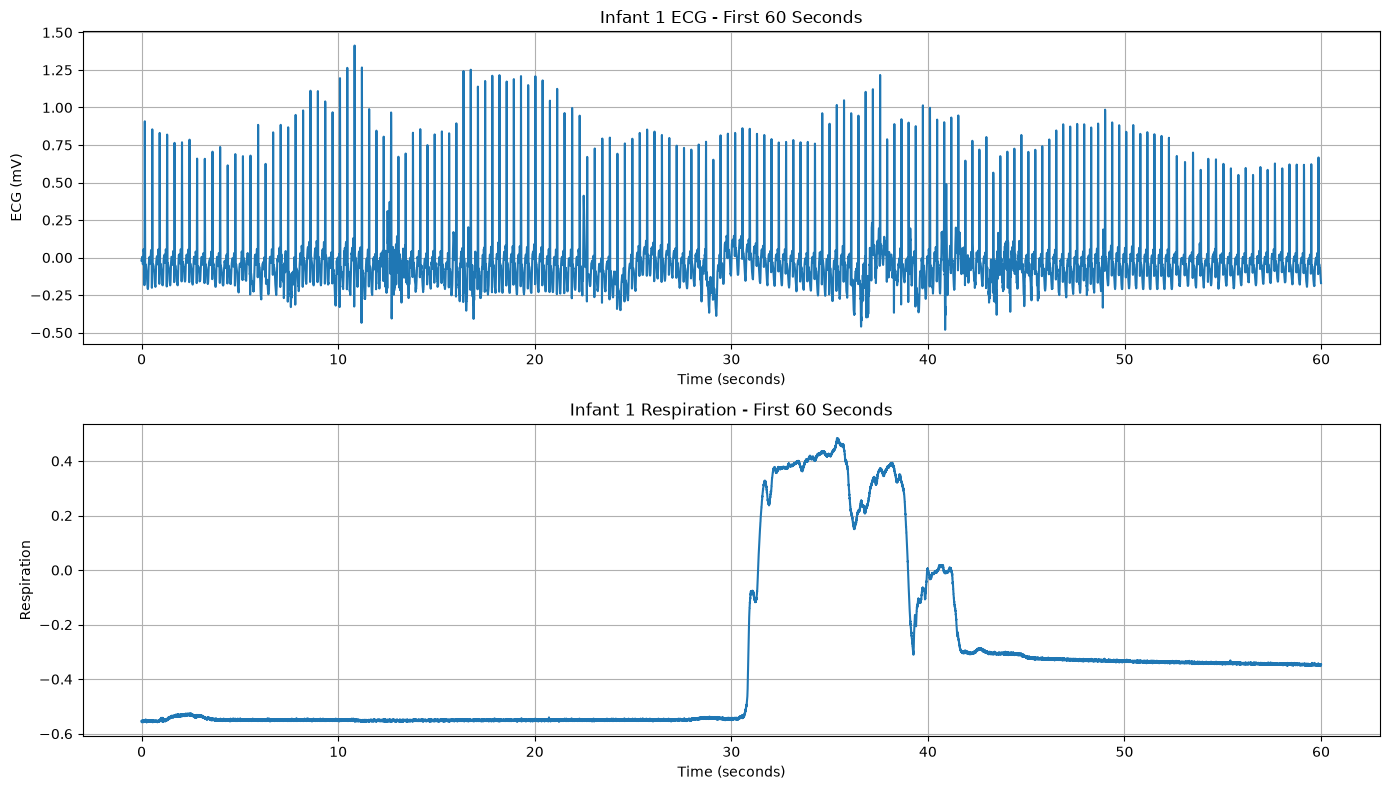

In [4]:
# Plot ECG and respiration for the first 60 seconds

time_ecg = np.arange(len(ecg)) / ecg_record.fs
time_resp = np.arange(len(respiration)) / resp_record.fs

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ECG
axes[0].plot(time_ecg, ecg)
axes[0].set_title("Infant 1 ECG - First 60 Seconds")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("ECG (mV)")
axes[0].grid(True)

# Respiration
axes[1].plot(time_resp, respiration)
axes[1].set_title("Infant 1 Respiration - First 60 Seconds")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Respiration")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [5]:
# Bandpass filter the respiration signal

RESP_LOW = 0.1
RESP_HIGH = 2.0
RESP_FILTER_ORDER = 4

nyquist_resp = 0.5 * resp_record.fs

low_resp = RESP_LOW / nyquist_resp
high_resp = RESP_HIGH / nyquist_resp

b_resp, a_resp = butter(
    RESP_FILTER_ORDER,
    [low_resp, high_resp],
    btype="band"
)

respiration_filtered = filtfilt(
    b_resp,
    a_resp,
    respiration
)

print("Respiration filter applied.")
print("Filter:", RESP_LOW, "-", RESP_HIGH, "Hz")
print("Filter order:", RESP_FILTER_ORDER)
print("Filtered respiration range:",
      np.min(respiration_filtered),
      "to",
      np.max(respiration_filtered))

Respiration filter applied.
Filter: 0.1 - 2.0 Hz
Filter order: 4
Filtered respiration range: -2.1933669846808505e+132 to 1.0614144317472006e+131


In [6]:
# Stable bandpass filter for respiration

from scipy.signal import butter, sosfiltfilt

RESP_LOW = 0.1
RESP_HIGH = 2.0
RESP_FILTER_ORDER = 4

# Design filter using second-order sections for numerical stability
sos_resp = butter(
    RESP_FILTER_ORDER,
    [RESP_LOW, RESP_HIGH],
    btype="band",
    fs=resp_record.fs,
    output="sos"
)

# Apply zero-phase filtering
respiration_filtered = sosfiltfilt(
    sos_resp,
    respiration
)

print("Respiration filter applied successfully.")
print("Filter:", RESP_LOW, "-", RESP_HIGH, "Hz")
print("Filter order:", RESP_FILTER_ORDER)
print("Filtered respiration range:",
      np.min(respiration_filtered),
      "to",
      np.max(respiration_filtered))

Respiration filter applied successfully.
Filter: 0.1 - 2.0 Hz
Filter order: 4
Filtered respiration range: -0.36832415500092863 to 0.30126411865875413


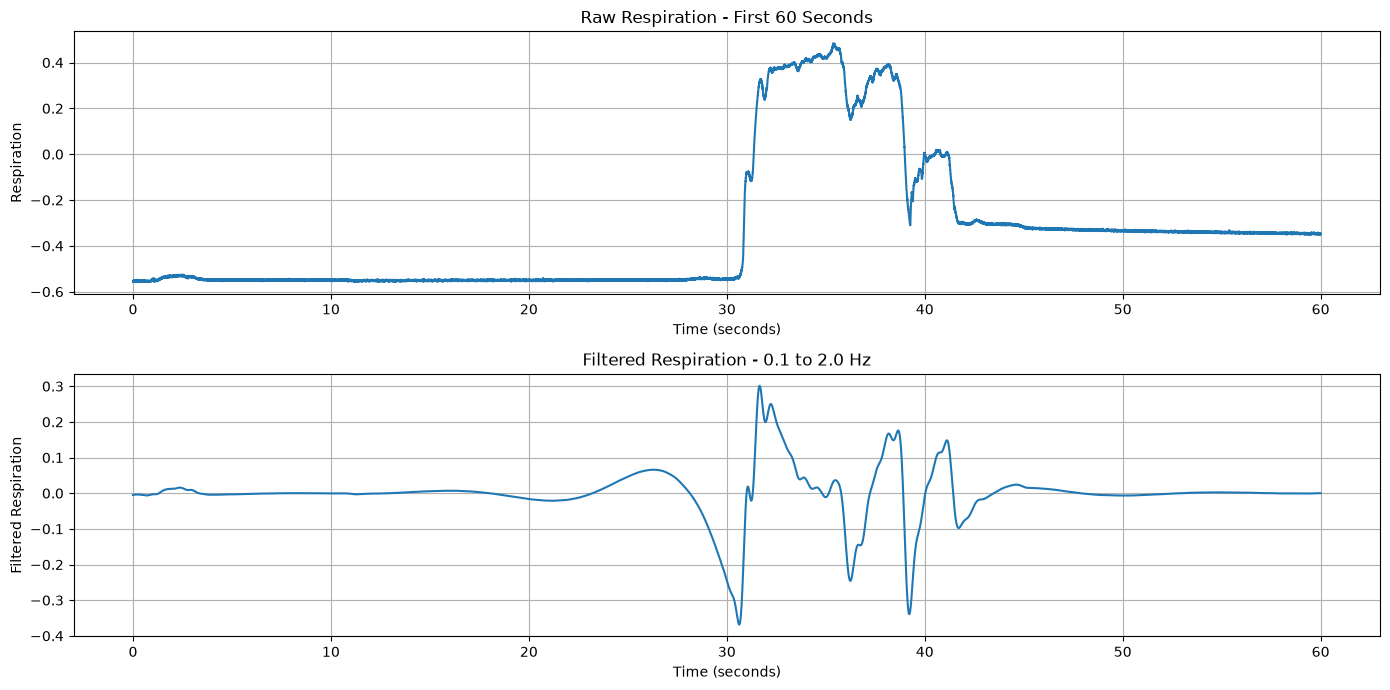

In [7]:
# Compare raw and filtered respiration

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Raw respiration
axes[0].plot(time_resp, respiration)
axes[0].set_title("Raw Respiration - First 60 Seconds")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Respiration")
axes[0].grid(True)

# Filtered respiration
axes[1].plot(time_resp, respiration_filtered)
axes[1].set_title("Filtered Respiration - 0.1 to 2.0 Hz")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Filtered Respiration")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [8]:
# Load bradycardia annotations for Infant 1

brady_annotation = wfdb.rdann(
    "infant1_ecg",
    "atr",
    pn_dir="picsdb/1.0.0"
)

brady_times = brady_annotation.sample / ecg_record.fs

print("Bradycardia annotations loaded successfully.")
print("Total annotations:", len(brady_times))

print("\nFirst 10 annotation times (seconds):")
print(brady_times[:10])

print("\nFirst 10 annotation symbols:")
print(brady_annotation.symbol[:10])

Bradycardia annotations loaded successfully.
Total annotations: 77

First 10 annotation times (seconds):
[ 1971.372  3456.512  3937.996  4834.748  7696.272  8246.66  13109.66
 14684.788 16371.744 17118.1  ]

First 10 annotation symbols:
['[', '[', '[', '[', '[', '[', '[', '[', '[', '[']


In [9]:
# Inspect bradycardia annotation symbols and timing

unique_symbols, symbol_counts = np.unique(
    brady_annotation.symbol,
    return_counts=True
)

print("Annotation symbol counts:")
for symbol, count in zip(unique_symbols, symbol_counts):
    print(f"  {symbol}: {count}")

print("\nAll bradycardia episode start times (seconds):")
print(brady_times)

print("\nRecording duration from ECG (seconds):",
      ecg_record.sig_len / ecg_record.fs)

Annotation symbol counts:
  [: 77

All bradycardia episode start times (seconds):
[  1971.372   3456.512   3937.996   4834.748   7696.272   8246.66
  13109.66   14684.788  16371.744  17118.1    17899.956  19840.38
  24526.424  25520.484  30321.336  35358.6    39795.228  45575.216
  50027.052  52366.7    55483.34   58971.484  60665.1    61305.304
  61934.92   63893.684  64898.872  70119.78   72603.04   72974.988
  76970.768  77883.988  79751.4    81012.384  82945.04   84939.052
  85334.016  86704.388  87919.18   89995.724  90950.524  92347.068
  93217.42   95612.404  97379.032  97748.224  99073.5   102578.608
 103246.368 104274.592 105264.096 108200.128 110052.48  111186.716
 115500.02  118023.084 119451.404 120904.204 124421.068 125225.2
 125720.692 126771.824 128434.004 131169.06  132496.676 138725.132
 140660.456 142670.312 146164.164 147831.032 148226.976 149462.036
 151761.096 155262.472 158891.608 160436.76  160831.724]

Recording duration from ECG (seconds): 60.0


In [10]:
# Check the full Infant 1 recording header

ecg_header = wfdb.rdheader(
    "infant1_ecg",
    pn_dir="picsdb/1.0.0"
)

full_ecg_duration = ecg_header.sig_len / ecg_header.fs

print("Full ECG sampling frequency:", ecg_header.fs)
print("Full ECG samples:", ecg_header.sig_len)
print("Full ECG duration (seconds):", full_ecg_duration)
print("Full ECG duration (hours):", full_ecg_duration / 3600)

print("\nFirst bradycardia annotation:", brady_times[0], "seconds")
print("Last bradycardia annotation:", brady_times[-1], "seconds")

Full ECG sampling frequency: 250
Full ECG samples: 41052191
Full ECG duration (seconds): 164208.764
Full ECG duration (hours): 45.613545555555554

First bradycardia annotation: 1971.372 seconds
Last bradycardia annotation: 160831.724 seconds


In [11]:
# Load a 60-second window around the first bradycardia event

EVENT_TIME = brady_times[0]

WINDOW_BEFORE = 30
WINDOW_AFTER = 30

window_start = EVENT_TIME - WINDOW_BEFORE
window_end = EVENT_TIME + WINDOW_AFTER

# ECG: 250 Hz
ecg_window = wfdb.rdrecord(
    "infant1_ecg",
    pn_dir="picsdb/1.0.0",
    sampfrom=int(window_start * 250),
    sampto=int(window_end * 250)
)

# Respiration: 500 Hz
resp_window = wfdb.rdrecord(
    "infant1_resp",
    pn_dir="picsdb/1.0.0",
    sampfrom=int(window_start * 500),
    sampto=int(window_end * 500)
)

ecg_event = ecg_window.p_signal[:, 0]
resp_event = resp_window.p_signal[:, 0]

print("Event time:", EVENT_TIME, "seconds")
print("Window:", window_start, "to", window_end, "seconds")

print("\nECG samples:", len(ecg_event))
print("ECG sampling frequency:", ecg_window.fs)

print("\nRespiration samples:", len(resp_event))
print("Respiration sampling frequency:", resp_window.fs)

Event time: 1971.372 seconds
Window: 1941.372 to 2001.372 seconds

ECG samples: 15000
ECG sampling frequency: 250

Respiration samples: 30000
Respiration sampling frequency: 500


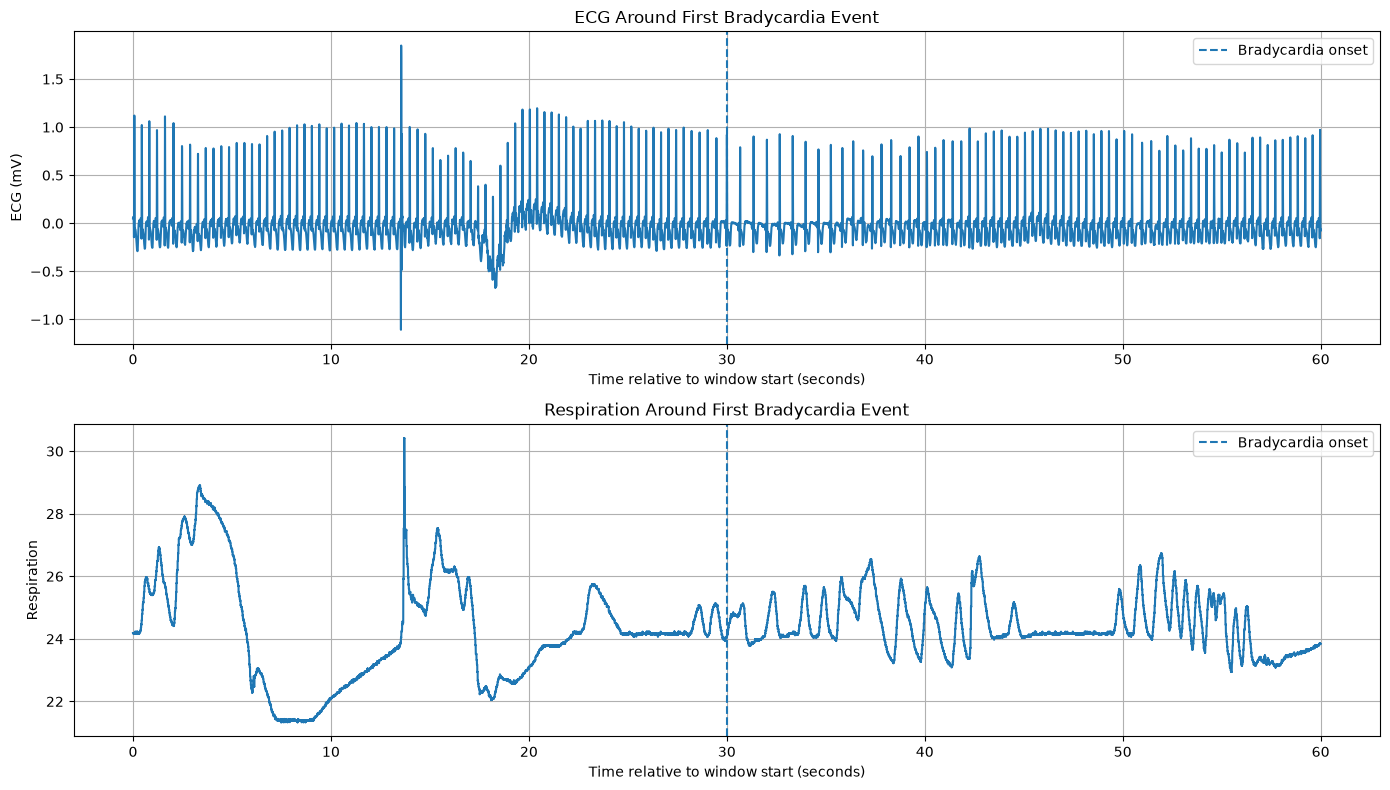

In [12]:
# Plot ECG and respiration around the first bradycardia event

time_ecg_event = (
    np.arange(len(ecg_event)) / ecg_event.size * 60
)

time_resp_event = (
    np.arange(len(resp_event)) / resp_event.size * 60
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ECG
axes[0].plot(time_ecg_event, ecg_event)
axes[0].axvline(
    WINDOW_BEFORE,
    linestyle="--",
    label="Bradycardia onset"
)
axes[0].set_title("ECG Around First Bradycardia Event")
axes[0].set_xlabel("Time relative to window start (seconds)")
axes[0].set_ylabel("ECG (mV)")
axes[0].legend()
axes[0].grid(True)

# Respiration
axes[1].plot(time_resp_event, resp_event)
axes[1].axvline(
    WINDOW_BEFORE,
    linestyle="--",
    label="Bradycardia onset"
)
axes[1].set_title("Respiration Around First Bradycardia Event")
axes[1].set_xlabel("Time relative to window start (seconds)")
axes[1].set_ylabel("Respiration")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [13]:
# Detect R-peaks in the neonatal ECG event window

ecg_peaks, ecg_peak_properties = find_peaks(
    ecg_event,
    distance=int(0.30 * ecg_record.fs),
    prominence=0.3
)

ecg_peak_times = ecg_peaks / ecg_record.fs

print("R-peaks detected:", len(ecg_peaks))
print("\nFirst 10 R-peak times (seconds):")
print(ecg_peak_times[:10])

if len(ecg_peak_times) > 1:
    rr_event = np.diff(ecg_peak_times)

    print("\nRR intervals detected:", len(rr_event))
    print("Mean RR:", np.mean(rr_event), "seconds")
    print("Mean HR:", 60 / np.mean(rr_event), "BPM")
    print("Minimum HR:", 60 / np.max(rr_event), "BPM")
    print("Maximum HR:", 60 / np.min(rr_event), "BPM")

R-peaks detected: 147

First 10 R-peak times (seconds):
[0.068 0.444 0.824 1.212 1.616 2.048 2.476 2.884 3.284 3.676]

RR intervals detected: 146
Mean RR: 0.4102739726027398 seconds
Mean HR: 146.24373956594323 BPM
Minimum HR: 88.2352941176471 BPM
Maximum HR: 168.53932584269668 BPM


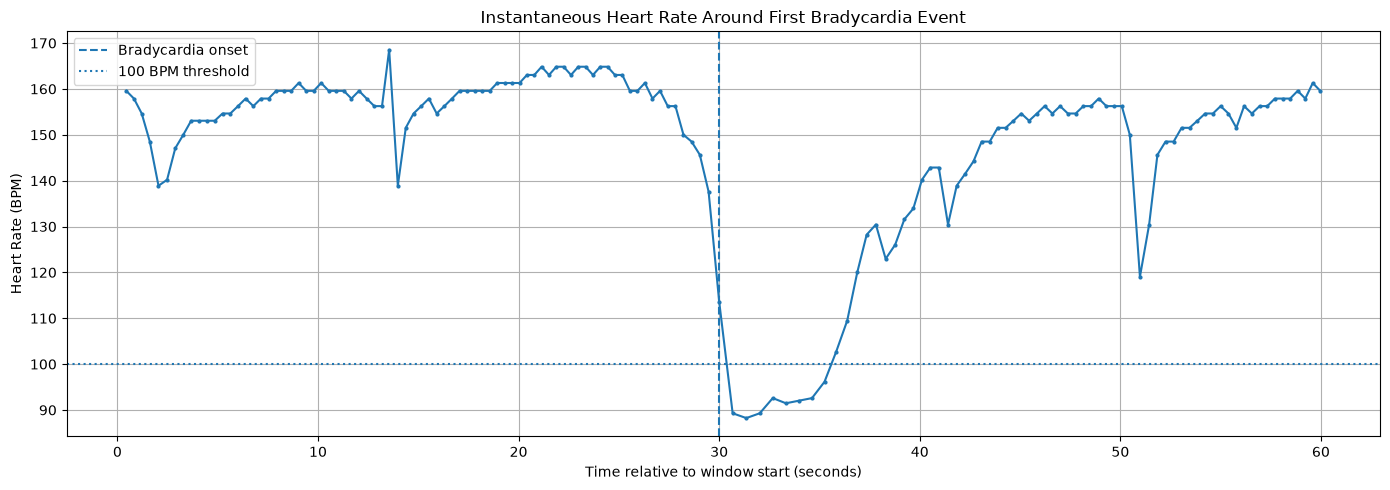

HR before bradycardia onset:
Mean: 157.38142903219344 BPM
Minimum: 137.61467889908258 BPM

HR after bradycardia onset:
Mean: 140.1153684337125 BPM
Minimum: 88.2352941176471 BPM


In [14]:
# Calculate and plot instantaneous heart rate

rr_event = np.diff(ecg_peak_times)
hr_event = 60 / rr_event

# HR is associated with the time of the second R-peak
hr_times = ecg_peak_times[1:]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(hr_times, hr_event, marker=".", markersize=4)

# Bradycardia annotation onset
ax.axvline(
    WINDOW_BEFORE,
    linestyle="--",
    label="Bradycardia onset"
)

# Bradycardia threshold from PICS definition
ax.axhline(
    100,
    linestyle=":",
    label="100 BPM threshold"
)

ax.set_title("Instantaneous Heart Rate Around First Bradycardia Event")
ax.set_xlabel("Time relative to window start (seconds)")
ax.set_ylabel("Heart Rate (BPM)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

print("HR before bradycardia onset:")
before_hr = hr_event[hr_times < WINDOW_BEFORE]
print("Mean:", np.mean(before_hr), "BPM")
print("Minimum:", np.min(before_hr), "BPM")

print("\nHR after bradycardia onset:")
after_hr = hr_event[hr_times >= WINDOW_BEFORE]
print("Mean:", np.mean(after_hr), "BPM")
print("Minimum:", np.min(after_hr), "BPM")

In [15]:
# Detect respiration peaks

resp_peaks, resp_peak_properties = find_peaks(
    resp_event,
    distance=int(1.0 * resp_record.fs),
    prominence=0.05
)

resp_peak_times = resp_peaks / resp_record.fs

print("Respiration peaks detected:", len(resp_peaks))

print("\nFirst 10 respiration peak times (seconds):")
print(resp_peak_times[:10])

if len(resp_peak_times) > 1:
    breath_intervals = np.diff(resp_peak_times)

    print("\nBreath intervals detected:", len(breath_intervals))
    print("Mean breath interval:",
          np.mean(breath_intervals), "seconds")

    print("Minimum breath interval:",
          np.min(breath_intervals), "seconds")

    print("Maximum breath interval:",
          np.max(breath_intervals), "seconds")

    print("Estimated respiratory rate:",
          60 / np.mean(breath_intervals), "breaths/min")

Respiration peaks detected: 36

First 10 respiration peak times (seconds):
[ 0.106  1.324  3.388  8.138 12.662 13.698 15.384 16.974 18.54  19.976]

Breath intervals detected: 35
Mean breath interval: 1.635314285714286 seconds
Minimum breath interval: 1.0020000000000024 seconds
Maximum breath interval: 4.75 seconds
Estimated respiratory rate: 36.690194982179044 breaths/min


In [16]:
# Analyze breath-to-breath intervals

breath_intervals = np.diff(resp_peak_times)

print("Number of breath intervals:", len(breath_intervals))

print("\nBreath intervals (seconds):")
print(np.round(breath_intervals, 3))

print("\nIntervals >= 5 seconds:")
long_intervals = breath_intervals[breath_intervals >= 5.0]

if len(long_intervals) > 0:
    print(long_intervals)
else:
    print("No intervals >= 5 seconds detected.")

print("\nLongest breath interval:",
      np.max(breath_intervals), "seconds")

print("Mean breath interval:",
      np.mean(breath_intervals), "seconds")

Number of breath intervals: 35

Breath intervals (seconds):
[1.218 2.064 4.75  4.524 1.036 1.686 1.59  1.566 1.436 1.002 1.262 1.016
 2.49  1.6   2.068 1.378 1.508 1.668 1.84  1.47  1.514 1.33  1.588 1.052
 1.732 1.098 1.602 1.34  1.288 1.054 1.092 1.204 1.216 1.878 1.076]

Intervals >= 5 seconds:
No intervals >= 5 seconds detected.

Longest breath interval: 4.75 seconds
Mean breath interval: 1.635314285714286 seconds


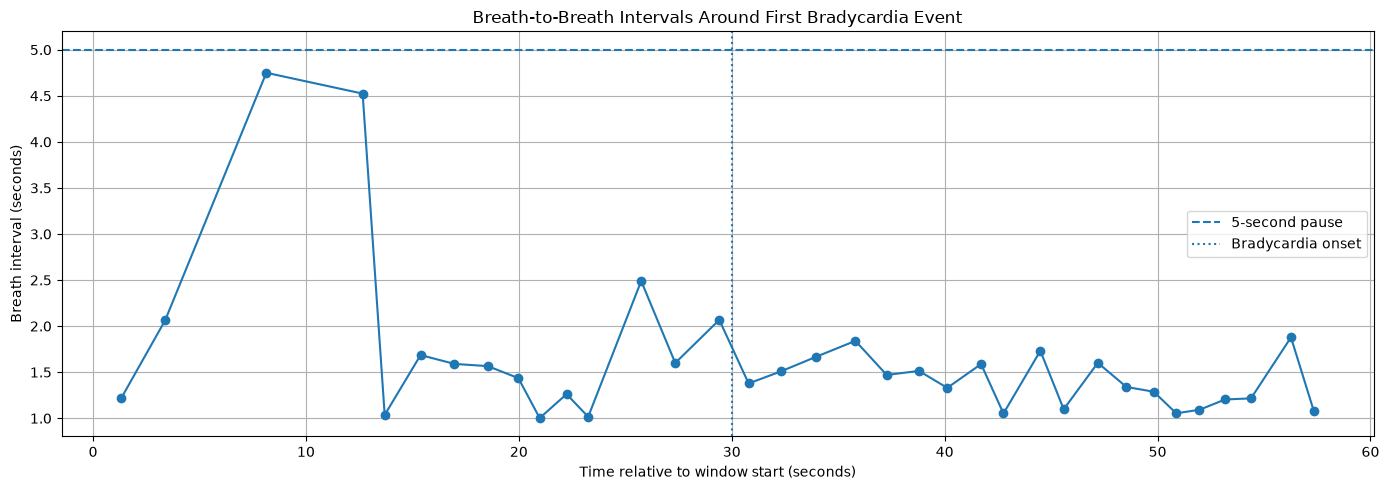

Longest interval: 4.75 seconds
Longest interval occurs near: 8.138 seconds


In [17]:
# Plot breath-to-breath intervals

breath_interval_times = resp_peak_times[1:]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    breath_interval_times,
    breath_intervals,
    marker="o"
)

ax.axhline(
    5.0,
    linestyle="--",
    label="5-second pause"
)

ax.axvline(
    WINDOW_BEFORE,
    linestyle=":",
    label="Bradycardia onset"
)

ax.set_title("Breath-to-Breath Intervals Around First Bradycardia Event")
ax.set_xlabel("Time relative to window start (seconds)")
ax.set_ylabel("Breath interval (seconds)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

print("Longest interval:",
      np.max(breath_intervals), "seconds")

longest_index = np.argmax(breath_intervals)

print("Longest interval occurs near:",
      breath_interval_times[longest_index], "seconds")

In [18]:
# Detect candidate respiratory pauses

PAUSE_THRESHOLD = 5.0  # seconds - exploratory threshold

candidate_pauses = []

for i, interval in enumerate(breath_intervals):
    if interval >= PAUSE_THRESHOLD:
        pause_start = resp_peak_times[i]
        pause_end = resp_peak_times[i + 1]

        candidate_pauses.append(
            {
                "start": pause_start,
                "end": pause_end,
                "duration": interval
            }
        )

candidate_pauses_df = pd.DataFrame(candidate_pauses)

print("Candidate pauses detected:", len(candidate_pauses))

if len(candidate_pauses_df) > 0:
    print("\nCandidate pauses:")
    print(candidate_pauses_df)
else:
    print("\nNo candidate pauses >= 5 seconds detected.")

Candidate pauses detected: 0

No candidate pauses >= 5 seconds detected.


In [19]:
# Find the bradycardia events that occur closest to long respiratory intervals

brady_pause_analysis = []

for brady_time in brady_times:

    # Find the respiration interval containing the bradycardia onset
    interval_index = np.searchsorted(resp_peak_times, brady_time) - 1

    if 0 <= interval_index < len(breath_intervals):

        interval_start = resp_peak_times[interval_index]
        interval_end = resp_peak_times[interval_index + 1]
        interval_duration = breath_intervals[interval_index]

        brady_pause_analysis.append([
            brady_time,
            interval_start,
            interval_end,
            interval_duration
        ])

brady_pause_df = pd.DataFrame(
    brady_pause_analysis,
    columns=[
        "brady_time",
        "resp_start",
        "resp_end",
        "breath_interval"
    ]
)

# Sort by longest respiratory interval
brady_pause_df = brady_pause_df.sort_values(
    "breath_interval",
    ascending=False
)

print("Bradycardia events analyzed:", len(brady_pause_df))

print("\nTop 10 bradycardia events associated with longest respiratory intervals:")
print(
    brady_pause_df.head(10).to_string(index=False)
)

Bradycardia events analyzed: 0

Top 10 bradycardia events associated with longest respiratory intervals:
Empty DataFrame
Columns: [brady_time, resp_start, resp_end, breath_interval]
Index: []


In [20]:
# Convert respiration peak times to absolute recording time

resp_peak_times_absolute = (
    window_start + resp_peak_times
)

print("Respiration peak times - relative:")
print(resp_peak_times[:10])

print("\nRespiration peak times - absolute:")
print(resp_peak_times_absolute[:10])

print("\nBradycardia event time:")
print(EVENT_TIME)

Respiration peak times - relative:
[ 0.106  1.324  3.388  8.138 12.662 13.698 15.384 16.974 18.54  19.976]

Respiration peak times - absolute:
[1941.478 1942.696 1944.76  1949.51  1954.034 1955.07  1956.756 1958.346
 1959.912 1961.348]

Bradycardia event time:
1971.372


In [21]:
# Match the first bradycardia event to the surrounding respiration interval

brady_time = EVENT_TIME

# Find the respiration interval containing the bradycardia onset
interval_index = np.searchsorted(
    resp_peak_times_absolute,
    brady_time
) - 1

if 0 <= interval_index < len(breath_intervals):

    resp_start = resp_peak_times_absolute[interval_index]
    resp_end = resp_peak_times_absolute[interval_index + 1]
    interval_duration = breath_intervals[interval_index]

    print("Bradycardia onset:", brady_time, "seconds")

    print("\nRespiration peak before bradycardia:")
    print(resp_start, "seconds")

    print("\nRespiration peak after bradycardia:")
    print(resp_end, "seconds")

    print("\nBreath-to-breath interval containing bradycardia:")
    print(interval_duration, "seconds")

else:
    print("Bradycardia event is outside the respiration window.")

Bradycardia onset: 1971.372 seconds

Respiration peak before bradycardia:
1970.786 seconds

Respiration peak after bradycardia:
1972.164 seconds

Breath-to-breath interval containing bradycardia:
1.3780000000000001 seconds


In [22]:
# Select the first 10 bradycardia events for respiratory analysis

events_to_test = brady_times[:10]

print("Bradycardia events selected:", len(events_to_test))
print("\nEvent times (seconds):")

for i, event_time in enumerate(events_to_test, start=1):
    print(f"Event {i}: {event_time:.3f} s")

Bradycardia events selected: 10

Event times (seconds):
Event 1: 1971.372 s
Event 2: 3456.512 s
Event 3: 3937.996 s
Event 4: 4834.748 s
Event 5: 7696.272 s
Event 6: 8246.660 s
Event 7: 13109.660 s
Event 8: 14684.788 s
Event 9: 16371.744 s
Event 10: 17118.100 s


In [23]:
# Load a 60-second window around Bradycardia Event 2

EVENT_INDEX = 1
EVENT_TIME = events_to_test[EVENT_INDEX]

WINDOW_BEFORE = 30
WINDOW_AFTER = 30

window_start = EVENT_TIME - WINDOW_BEFORE
window_end = EVENT_TIME + WINDOW_AFTER

resp_event2_record = wfdb.rdrecord(
    "infant1_resp",
    pn_dir="picsdb/1.0.0",
    sampfrom=int(window_start * 500),
    sampto=int(window_end * 500)
)

resp_event2 = resp_event2_record.p_signal[:, 0]

print("Event 2 time:", EVENT_TIME, "seconds")
print("Window:", window_start, "to", window_end, "seconds")
print("Respiration samples:", len(resp_event2))
print("Sampling frequency:", resp_event2_record.fs)

Event 2 time: 3456.512 seconds
Window: 3426.512 to 3486.512 seconds
Respiration samples: 30000
Sampling frequency: 500


In [24]:
# Filter respiration around Bradycardia Event 2

sos_resp_event2 = butter(
    RESP_FILTER_ORDER,
    [RESP_LOW, RESP_HIGH],
    btype="band",
    fs=resp_event2_record.fs,
    output="sos"
)

resp_event2_filtered = sosfiltfilt(
    sos_resp_event2,
    resp_event2
)

print("Event 2 respiration filtered successfully.")
print("Filtered range:",
      np.min(resp_event2_filtered),
      "to",
      np.max(resp_event2_filtered))

Event 2 respiration filtered successfully.
Filtered range: -2.2255600567368075 to 3.090988845880511


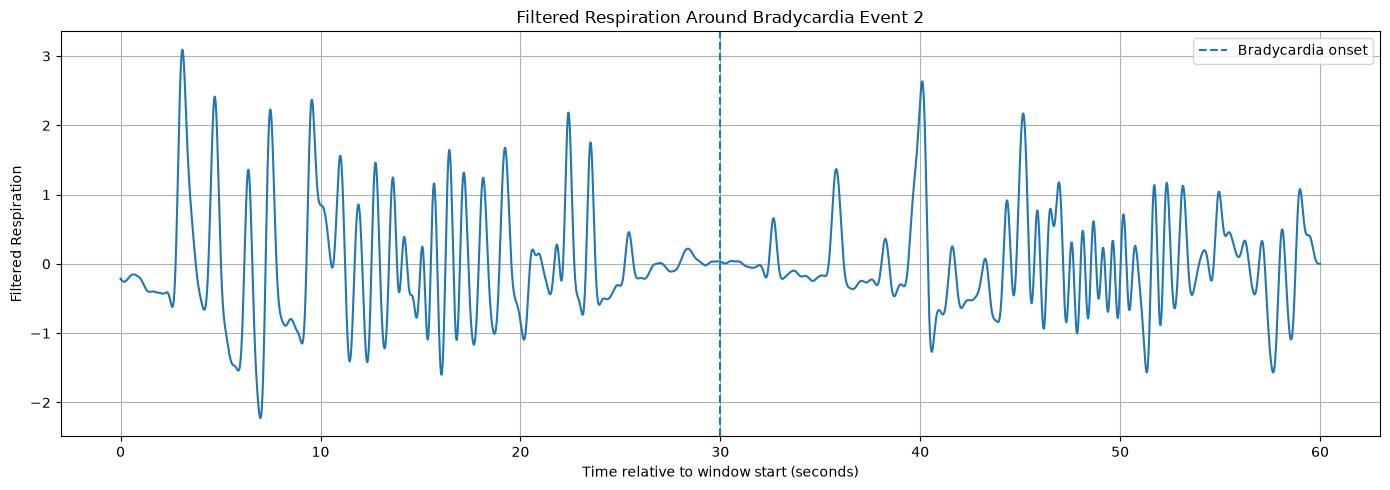

In [25]:
# Plot filtered respiration around Bradycardia Event 2

time_resp_event2 = (
    np.arange(len(resp_event2_filtered))
    / resp_event2_record.fs
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(time_resp_event2, resp_event2_filtered)

ax.axvline(
    WINDOW_BEFORE,
    linestyle="--",
    label="Bradycardia onset"
)

ax.set_title("Filtered Respiration Around Bradycardia Event 2")
ax.set_xlabel("Time relative to window start (seconds)")
ax.set_ylabel("Filtered Respiration")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [26]:
# Measure respiration activity using rolling RMS

RMS_WINDOW_SECONDS = 2
RMS_WINDOW_SAMPLES = int(
    RMS_WINDOW_SECONDS * resp_event2_record.fs
)

respiration_rms = np.sqrt(
    pd.Series(resp_event2_filtered ** 2)
    .rolling(
        window=RMS_WINDOW_SAMPLES,
        center=True
    )
    .mean()
    .to_numpy()
)

print("RMS calculated successfully.")
print("RMS samples:", len(respiration_rms))

print("\nMaximum RMS:", np.nanmax(respiration_rms))
print("Minimum RMS:", np.nanmin(respiration_rms))
print("Median RMS:", np.nanmedian(respiration_rms))

RMS calculated successfully.
RMS samples: 30000

Maximum RMS: 1.58665808296374
Minimum RMS: 0.028211536970119314
Median RMS: 0.6694103461839747


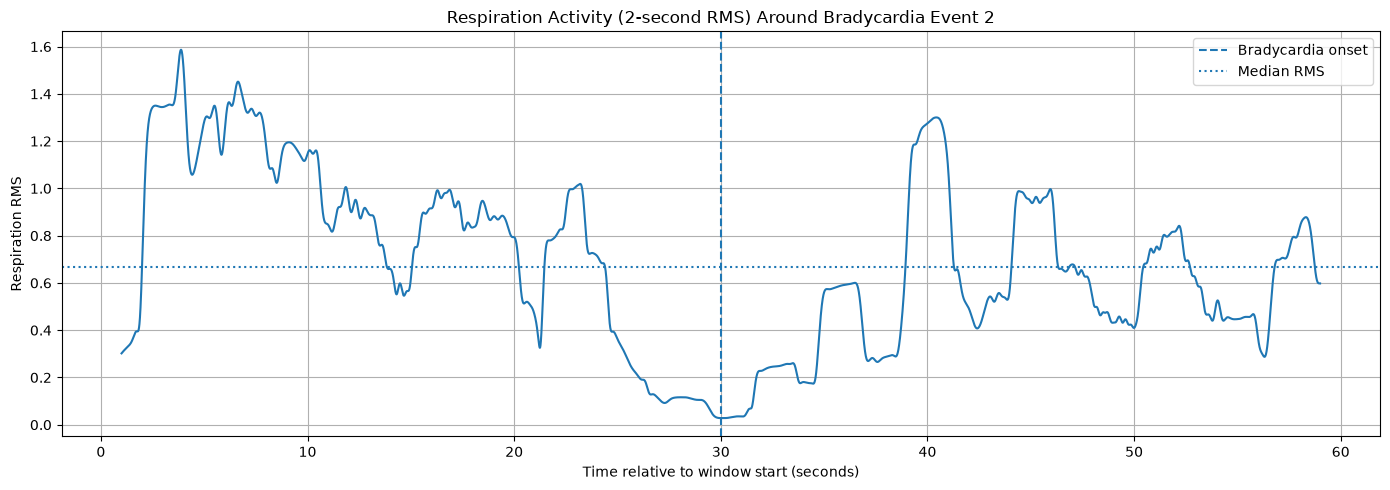

In [27]:
# Plot respiration RMS activity

time_rms = np.arange(len(respiration_rms)) / resp_event2_record.fs

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(time_rms, respiration_rms)

ax.axvline(
    WINDOW_BEFORE,
    linestyle="--",
    label="Bradycardia onset"
)

ax.axhline(
    np.nanmedian(respiration_rms),
    linestyle=":",
    label="Median RMS"
)

ax.set_title("Respiration Activity (2-second RMS) Around Bradycardia Event 2")
ax.set_xlabel("Time relative to window start (seconds)")
ax.set_ylabel("Respiration RMS")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [28]:
# Identify periods of unusually low respiratory activity

RMS_THRESHOLD_FACTOR = 0.20

rms_threshold = (
    RMS_THRESHOLD_FACTOR *
    np.nanmedian(respiration_rms)
)

low_respiration = (
    respiration_rms < rms_threshold
)

# Find continuous low-respiration regions
low_regions = []

start_index = None

for i, is_low in enumerate(low_respiration):

    if is_low and start_index is None:
        start_index = i

    elif not is_low and start_index is not None:
        end_index = i

        start_time = time_rms[start_index]
        end_time = time_rms[end_index - 1]
        duration = end_time - start_time

        low_regions.append([
            start_time,
            end_time,
            duration
        ])

        start_index = None

# Handle region reaching the end
if start_index is not None:
    end_index = len(low_respiration)

    start_time = time_rms[start_index]
    end_time = time_rms[end_index - 1]
    duration = end_time - start_time

    low_regions.append([
        start_time,
        end_time,
        duration
    ])

low_regions_df = pd.DataFrame(
    low_regions,
    columns=["start", "end", "duration"]
)

print("Adaptive RMS threshold:", rms_threshold)
print("\nLow-respiration regions detected:",
      len(low_regions_df))

print("\nRegions lasting at least 2 seconds:")

if len(low_regions_df) > 0:
    print(
        low_regions_df[
            low_regions_df["duration"] >= 2
        ].to_string(index=False)
    )
else:
    print("None")

Adaptive RMS threshold: 0.13388206923679494

Low-respiration regions detected: 1

Regions lasting at least 2 seconds:
 start   end  duration
26.532 31.61     5.078


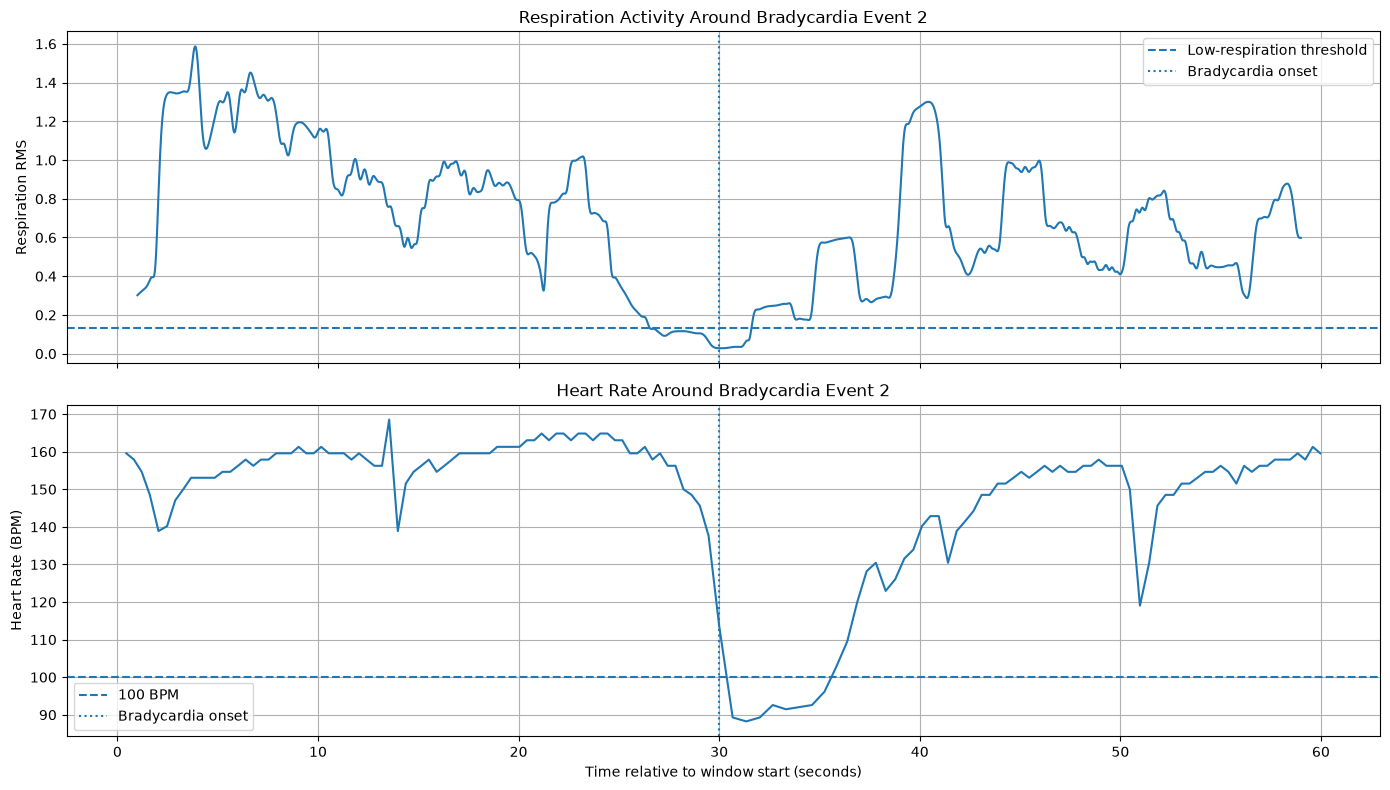

In [29]:
# Compare respiration activity and heart rate around Event 2

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Respiration RMS
axes[0].plot(time_rms, respiration_rms)

axes[0].axhline(
    rms_threshold,
    linestyle="--",
    label="Low-respiration threshold"
)

axes[0].axvline(
    WINDOW_BEFORE,
    linestyle=":",
    label="Bradycardia onset"
)

axes[0].set_title("Respiration Activity Around Bradycardia Event 2")
axes[0].set_ylabel("Respiration RMS")
axes[0].legend()
axes[0].grid(True)

# Heart rate
axes[1].plot(hr_times, hr_event)

axes[1].axhline(
    100,
    linestyle="--",
    label="100 BPM"
)

axes[1].axvline(
    WINDOW_BEFORE,
    linestyle=":",
    label="Bradycardia onset"
)

axes[1].set_title("Heart Rate Around Bradycardia Event 2")
axes[1].set_xlabel("Time relative to window start (seconds)")
axes[1].set_ylabel("Heart Rate (BPM)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [30]:
# Reusable respiratory activity detector

def detect_low_respiration(
    respiration_signal,
    fs,
    low_cut=0.1,
    high_cut=2.0,
    filter_order=4,
    rms_window_seconds=2.0,
    threshold_factor=0.20
):
    """
    Detect periods of unusually low respiratory activity.

    Returns:
        filtered_signal : filtered respiration
        rms_activity    : rolling RMS respiratory activity
        threshold       : adaptive RMS threshold
        low_activity    : boolean array
    """

    # Stable bandpass filter
    sos = butter(
        filter_order,
        [low_cut, high_cut],
        btype="band",
        fs=fs,
        output="sos"
    )

    filtered_signal = sosfiltfilt(
        sos,
        respiration_signal
    )

    # Calculate RMS activity
    window_samples = int(
        rms_window_seconds * fs
    )

    rms_activity = np.sqrt(
        pd.Series(filtered_signal ** 2)
        .rolling(
            window=window_samples,
            center=True
        )
        .mean()
        .to_numpy()
    )

    # Adaptive threshold
    threshold = (
        threshold_factor *
        np.nanmedian(rms_activity)
    )

    # Low-respiration regions
    low_activity = (
        rms_activity < threshold
    )

    return (
        filtered_signal,
        rms_activity,
        threshold,
        low_activity
    )


print("Respiratory activity detector created successfully.")

Respiratory activity detector created successfully.


In [31]:
# Load ECG around Bradycardia Event 2

ecg_event2_record = wfdb.rdrecord(
    "infant1_ecg",
    pn_dir="picsdb/1.0.0",
    sampfrom=int(window_start * 250),
    sampto=int(window_end * 250)
)

ecg_event2 = ecg_event2_record.p_signal[:, 0]

print("Event 2 ECG loaded successfully.")
print("ECG samples:", len(ecg_event2))
print("ECG sampling frequency:", ecg_event2_record.fs)
print("ECG duration:",
      len(ecg_event2) / ecg_event2_record.fs,
      "seconds")

Event 2 ECG loaded successfully.
ECG samples: 15000
ECG sampling frequency: 250
ECG duration: 60.0 seconds


In [32]:
# Detect R-peaks and calculate heart rate for Event 2

ecg_peaks2, ecg_peak_properties2 = find_peaks(
    ecg_event2,
    distance=int(0.30 * ecg_event2_record.fs),
    prominence=0.3
)

ecg_peak_times2 = ecg_peaks2 / ecg_event2_record.fs

print("R-peaks detected:", len(ecg_peaks2))

if len(ecg_peak_times2) > 1:

    rr_event2 = np.diff(ecg_peak_times2)
    hr_event2 = 60 / rr_event2
    hr_times2 = ecg_peak_times2[1:]

    print("RR intervals:", len(rr_event2))
    print("Mean HR:", np.mean(hr_event2), "BPM")
    print("Minimum HR:", np.min(hr_event2), "BPM")
    print("Maximum HR:", np.max(hr_event2), "BPM")

    before_hr2 = hr_event2[hr_times2 < WINDOW_BEFORE]
    after_hr2 = hr_event2[hr_times2 >= WINDOW_BEFORE]

    print("\nBefore bradycardia onset:")
    print("Mean HR:", np.mean(before_hr2), "BPM")
    print("Minimum HR:", np.min(before_hr2), "BPM")

    print("\nAfter bradycardia onset:")
    print("Mean HR:", np.mean(after_hr2), "BPM")
    print("Minimum HR:", np.min(after_hr2), "BPM")

R-peaks detected: 129
RR intervals: 128
Mean HR: 136.72267835809885 BPM
Minimum HR: 41.208791208791325 BPM
Maximum HR: 185.1851851851863 BPM

Before bradycardia onset:
Mean HR: 152.24134437469934 BPM
Minimum HR: 109.48905109489085 BPM

After bradycardia onset:
Mean HR: 115.45635826127601 BPM
Minimum HR: 41.208791208791325 BPM


In [33]:
# Inspect unusually long RR intervals in Event 2

suspicious_rr = rr_event2 > 0.8

print("RR intervals > 0.8 seconds:",
      np.sum(suspicious_rr))

print("\nSuspicious RR intervals:")

for i in np.where(suspicious_rr)[0]:
    print(
        f"Time: {hr_times2[i]:.3f} s | "
        f"RR: {rr_event2[i]:.3f} s | "
        f"HR: {hr_event2[i]:.1f} BPM"
    )

RR intervals > 0.8 seconds: 2

Suspicious RR intervals:
Time: 42.312 s | RR: 1.456 s | HR: 41.2 BPM
Time: 43.284 s | RR: 0.972 s | HR: 61.7 BPM


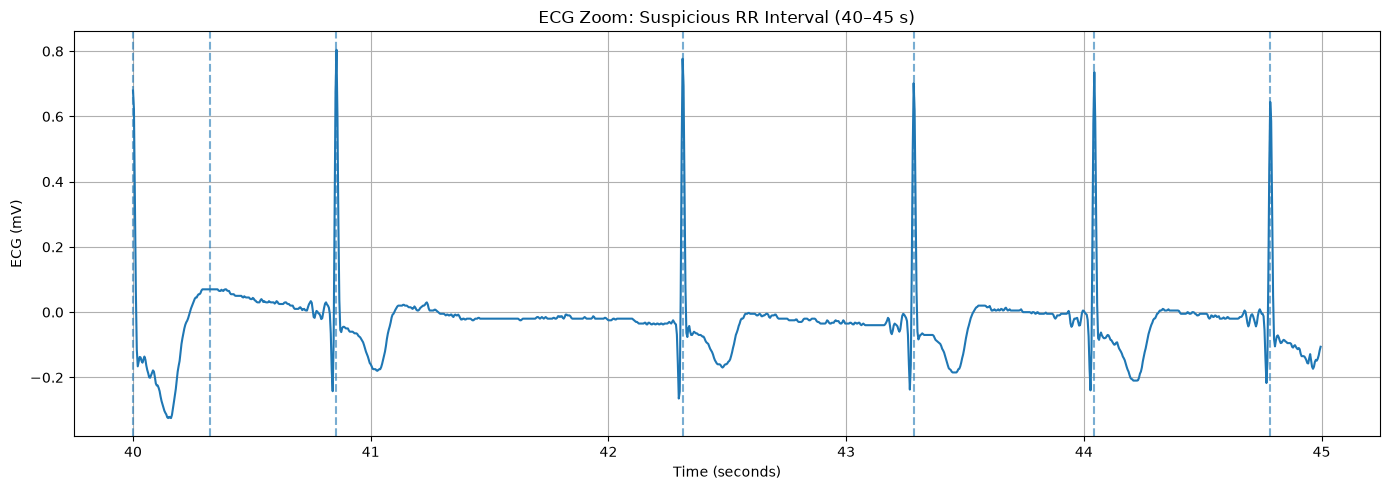

Detected R-peaks in this region:
[40.    40.324 40.856 42.312 43.284 44.044 44.784]


In [34]:
# Inspect the ECG around the suspicious long RR interval

ZOOM_START = 40
ZOOM_END = 45

start_sample = int(ZOOM_START * ecg_event2_record.fs)
end_sample = int(ZOOM_END * ecg_event2_record.fs)

zoom_ecg = ecg_event2[start_sample:end_sample]
zoom_time = np.arange(len(zoom_ecg)) / ecg_event2_record.fs + ZOOM_START

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(zoom_time, zoom_ecg)

# Mark detected R-peaks in this region
zoom_peaks = ecg_peak_times2[
    (ecg_peak_times2 >= ZOOM_START) &
    (ecg_peak_times2 <= ZOOM_END)
]

for peak_time in zoom_peaks:
    ax.axvline(
        peak_time,
        linestyle="--",
        alpha=0.6
    )

ax.set_title("ECG Zoom: Suspicious RR Interval (40–45 s)")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("ECG (mV)")
ax.grid(True)

plt.tight_layout()
plt.show()

print("Detected R-peaks in this region:")
print(zoom_peaks)

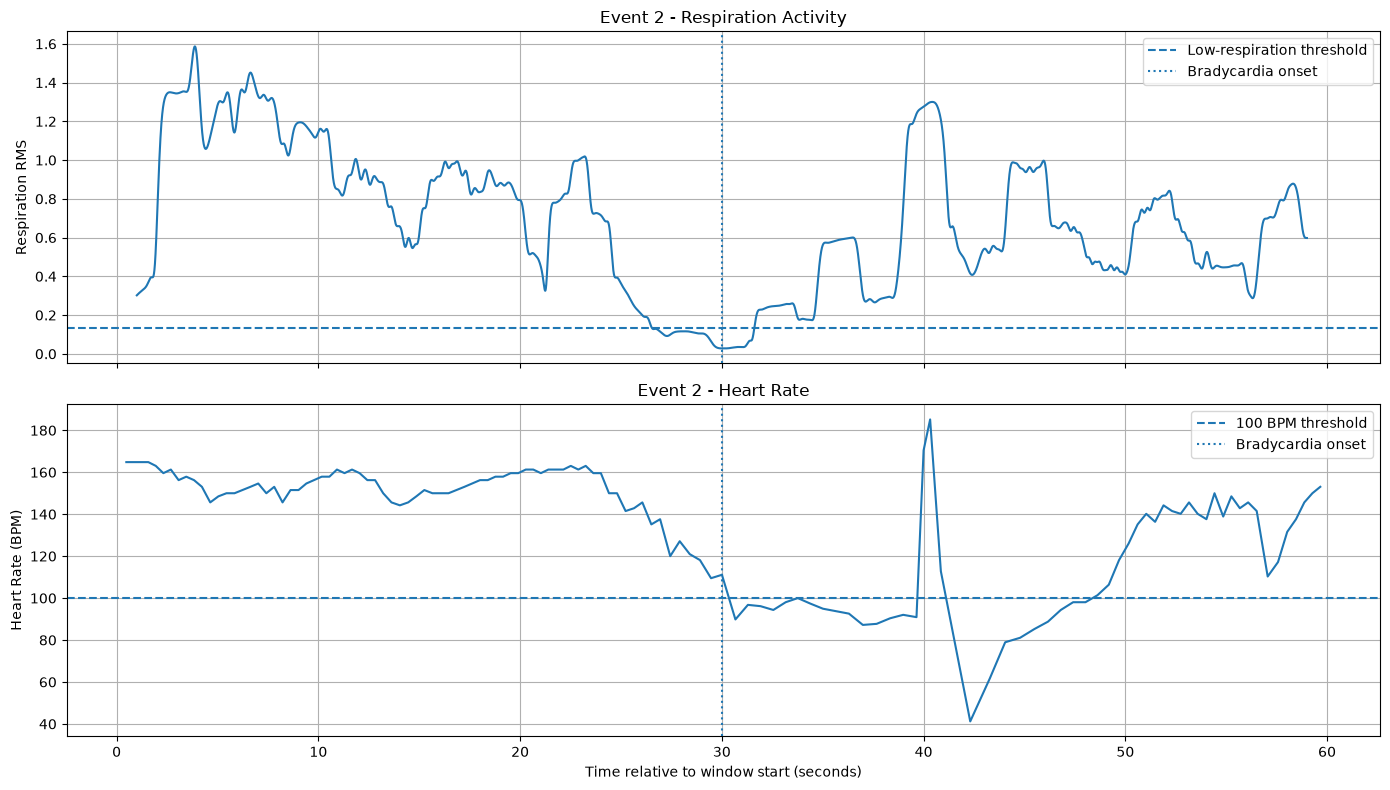

In [35]:
# Correct combined cardiorespiratory plot for Event 2

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Respiration RMS
axes[0].plot(time_rms, respiration_rms)

axes[0].axhline(
    rms_threshold,
    linestyle="--",
    label="Low-respiration threshold"
)

axes[0].axvline(
    WINDOW_BEFORE,
    linestyle=":",
    label="Bradycardia onset"
)

axes[0].set_title(
    "Event 2 - Respiration Activity"
)
axes[0].set_ylabel("Respiration RMS")
axes[0].legend()
axes[0].grid(True)

# Event 2 heart rate
axes[1].plot(hr_times2, hr_event2)

axes[1].axhline(
    100,
    linestyle="--",
    label="100 BPM threshold"
)

axes[1].axvline(
    WINDOW_BEFORE,
    linestyle=":",
    label="Bradycardia onset"
)

axes[1].set_title(
    "Event 2 - Heart Rate"
)
axes[1].set_xlabel(
    "Time relative to window start (seconds)"
)
axes[1].set_ylabel("Heart Rate (BPM)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

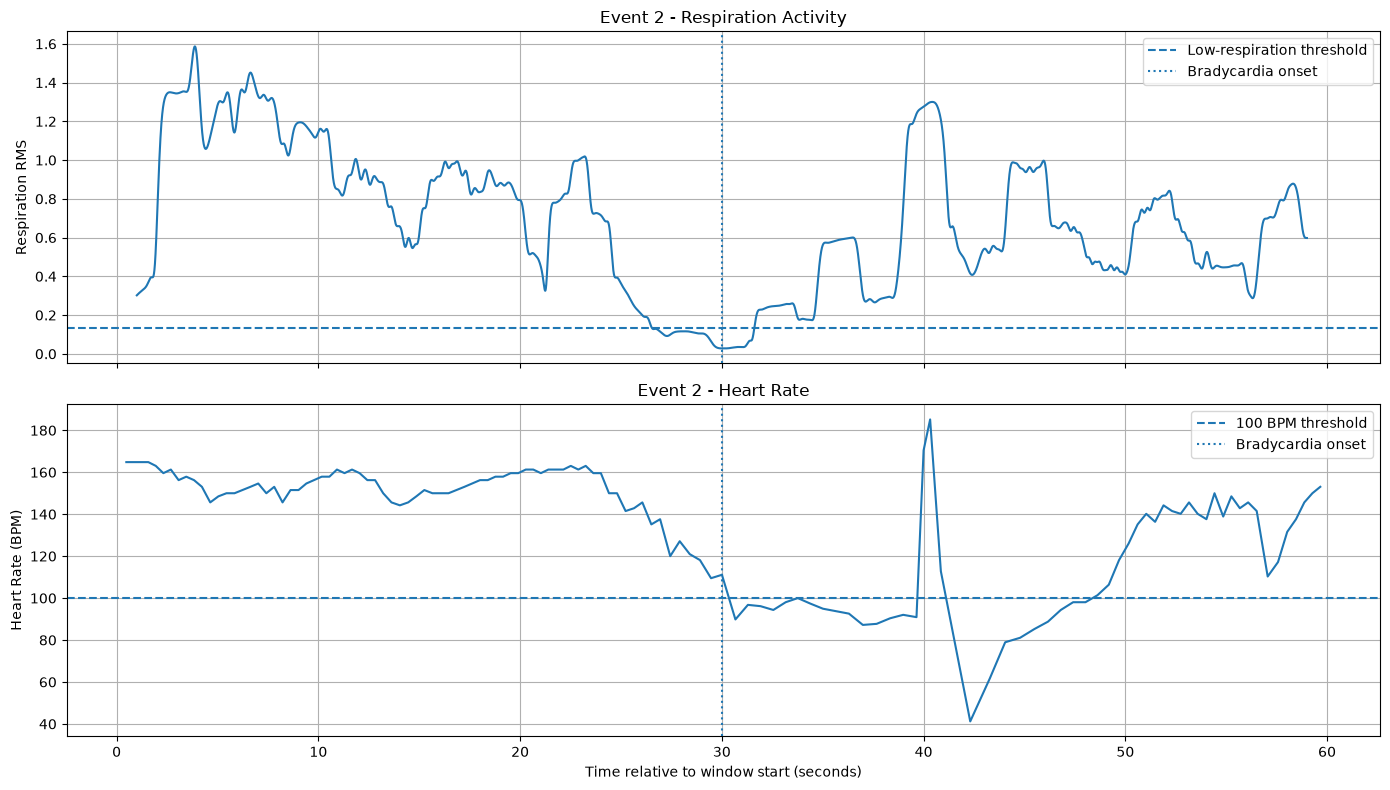

In [36]:
# Correct combined cardiorespiratory plot for Event 2

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Respiration RMS
axes[0].plot(time_rms, respiration_rms)

axes[0].axhline(
    rms_threshold,
    linestyle="--",
    label="Low-respiration threshold"
)

axes[0].axvline(
    WINDOW_BEFORE,
    linestyle=":",
    label="Bradycardia onset"
)

axes[0].set_title(
    "Event 2 - Respiration Activity"
)
axes[0].set_ylabel("Respiration RMS")
axes[0].legend()
axes[0].grid(True)

# Event 2 heart rate
axes[1].plot(hr_times2, hr_event2)

axes[1].axhline(
    100,
    linestyle="--",
    label="100 BPM threshold"
)

axes[1].axvline(
    WINDOW_BEFORE,
    linestyle=":",
    label="Bradycardia onset"
)

axes[1].set_title(
    "Event 2 - Heart Rate"
)
axes[1].set_xlabel(
    "Time relative to window start (seconds)"
)
axes[1].set_ylabel("Heart Rate (BPM)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [37]:
# Load official PICS ECG R-peak annotations for Infant 1

qrs_annotation = wfdb.rdann(
    "infant1_ecg",
    "qrsc",
    pn_dir="picsdb/1.0.0"
)

qrs_times_absolute = (
    qrs_annotation.sample / 250
)

# Keep official R-peaks inside Event 2 window
qrs_event2 = qrs_times_absolute[
    (qrs_times_absolute >= window_start) &
    (qrs_times_absolute <= window_end)
]

print("Total official QRS annotations:",
      len(qrs_times_absolute))

print("\nOfficial R-peaks in Event 2 window:",
      len(qrs_event2))

print("\nFirst 10 official R-peak times:")
print(qrs_event2[:10])

Total official QRS annotations: 419233

Official R-peaks in Event 2 window: 128

First 10 official R-peak times:
[3426.624 3426.988 3427.352 3427.712 3428.076 3428.448 3428.82  3429.192
 3429.576 3429.96 ]


In [38]:
# Compare detected R-peaks with official PICS QRS annotations

qrs_event2_relative = qrs_event2 - window_start

print("Our detected R-peaks:", len(ecg_peak_times2))
print("Official R-peaks:", len(qrs_event2_relative))

print("\nDetected vs official R-peaks around the suspicious region:")
print("\nOur detector:")

print(
    ecg_peak_times2[
        (ecg_peak_times2 >= 39) &
        (ecg_peak_times2 <= 45)
    ]
)

print("\nOfficial PICS annotations:")

print(
    qrs_event2_relative[
        (qrs_event2_relative >= 39) &
        (qrs_event2_relative <= 45)
    ]
)

Our detected R-peaks: 129
Official R-peaks: 128

Detected vs official R-peaks around the suspicious region:

Our detector:
[39.648 40.    40.324 40.856 42.312 43.284 44.044 44.784]

Official PICS annotations:
[39.644 39.996 40.848 42.308 43.28  44.04  44.78 ]


In [39]:
# Quantify our R-peak detector against the official PICS annotations

TOLERANCE = 0.05  # 50 ms

detected = ecg_peak_times2
official = qrs_event2_relative

matched_detected = []
matched_official = []

for d in detected:

    differences = np.abs(official - d)

    if len(differences) == 0:
        continue

    closest_index = np.argmin(differences)

    if differences[closest_index] <= TOLERANCE:
        if closest_index not in matched_official:
            matched_detected.append(d)
            matched_official.append(closest_index)

true_positives = len(matched_detected)

false_positives = len(detected) - true_positives

false_negatives = len(official) - true_positives

sensitivity = (
    true_positives / len(official)
    if len(official) > 0 else 0
)

precision = (
    true_positives / len(detected)
    if len(detected) > 0 else 0
)

print("Official R-peaks:", len(official))
print("Detected R-peaks:", len(detected))

print("\nTrue positives:", true_positives)
print("False positives:", false_positives)
print("False negatives:", false_negatives)

print("\nR-peak sensitivity:",
      round(sensitivity * 100, 2), "%")

print("R-peak precision:",
      round(precision * 100, 2), "%")

Official R-peaks: 128
Detected R-peaks: 129

True positives: 128
False positives: 1
False negatives: 0

R-peak sensitivity: 100.0 %
R-peak precision: 99.22 %


In [40]:
# Calculate duration of HR < 100 BPM around Event 2

BRADYCARDIA_THRESHOLD = 100.0

# Identify intervals where HR is below 100 BPM
below_100 = hr_event2 < BRADYCARDIA_THRESHOLD

# Find the first below-100 interval at or after bradycardia onset
post_onset_indices = np.where(
    (hr_times2 >= WINDOW_BEFORE) & below_100
)[0]

if len(post_onset_indices) > 0:

    start_idx = post_onset_indices[0]

    # Continue while HR remains below 100 BPM
    end_idx = start_idx

    while (
        end_idx + 1 < len(hr_event2)
        and below_100[end_idx + 1]
    ):
        end_idx += 1

    brady_start = hr_times2[start_idx]
    brady_end = hr_times2[end_idx]

    print("Bradycardia threshold:", BRADYCARDIA_THRESHOLD, "BPM")
    print("Detected bradycardia start:", brady_start, "seconds")
    print("Detected bradycardia end:", brady_end, "seconds")
    print("Duration:", brady_end - brady_start, "seconds")

else:
    print("No HR < 100 BPM detected after the annotated onset.")

Bradycardia threshold: 100.0 BPM
Detected bradycardia start: 30.672 seconds
Detected bradycardia end: 39.648 seconds
Duration: 8.976000000000003 seconds


In [41]:
# Quantify overlap between low respiration and bradycardia

low_resp_start = low_regions_df.iloc[0]["start"]
low_resp_end = low_regions_df.iloc[0]["end"]

brady_overlap_start = max(
    low_resp_start,
    brady_start
)

brady_overlap_end = min(
    low_resp_end,
    brady_end
)

overlap_duration = max(
    0,
    brady_overlap_end - brady_overlap_start
)

print("Low-respiration period:")
print(
    f"{low_resp_start:.3f} to "
    f"{low_resp_end:.3f} s"
)

print("\nBradycardia period:")
print(
    f"{brady_start:.3f} to "
    f"{brady_end:.3f} s"
)

print("\nOverlap:")
print(
    f"{brady_overlap_start:.3f} to "
    f"{brady_overlap_end:.3f} s"
)

print("\nOverlap duration:",
      round(overlap_duration, 3),
      "seconds")

Low-respiration period:
26.532 to 31.610 s

Bradycardia period:
30.672 to 39.648 s

Overlap:
30.672 to 31.610 s

Overlap duration: 0.938 seconds


In [42]:
# Reusable neonatal cardiorespiratory event analysis

def analyze_cardiorespiratory_event(
    event_time,
    window_before=30,
    window_after=30,
    ecg_fs=250,
    resp_fs=500,
    brady_threshold=100,
    rms_window_seconds=2,
    threshold_factor=0.20
):
    """
    Analyze ECG and respiration around a bradycardia event.

    Returns a dictionary containing:
    - HR statistics
    - bradycardia duration
    - respiratory low-activity regions
    - overlap between low respiration and bradycardia
    """

    start_time = event_time - window_before
    end_time = event_time + window_after

    # Load ECG
    ecg_record_local = wfdb.rdrecord(
        "infant1_ecg",
        pn_dir="picsdb/1.0.0",
        sampfrom=int(start_time * ecg_fs),
        sampto=int(end_time * ecg_fs)
    )

    ecg_local = ecg_record_local.p_signal[:, 0]

    # Load respiration
    resp_record_local = wfdb.rdrecord(
        "infant1_resp",
        pn_dir="picsdb/1.0.0",
        sampfrom=int(start_time * resp_fs),
        sampto=int(end_time * resp_fs)
    )

    resp_local = resp_record_local.p_signal[:, 0]

    # Detect ECG R-peaks
    peaks_local, _ = find_peaks(
        ecg_local,
        distance=int(0.30 * ecg_fs),
        prominence=0.3
    )

    peak_times = peaks_local / ecg_fs

    if len(peak_times) < 2:
        return None

    # Heart rate
    rr_local = np.diff(peak_times)
    hr_local = 60 / rr_local
    hr_times_local = peak_times[1:]

    # Bradycardia after event onset
    below_threshold = (
        (hr_times_local >= window_before) &
        (hr_local < brady_threshold)
    )

    brady_indices = np.where(below_threshold)[0]

    if len(brady_indices) > 0:

        brady_start_local = hr_times_local[
            brady_indices[0]
        ]

        brady_end_local = hr_times_local[
            brady_indices[-1]
        ]

        brady_duration = (
            brady_end_local -
            brady_start_local
        )

    else:
        brady_start_local = np.nan
        brady_end_local = np.nan
        brady_duration = 0

    # Filter respiration
    sos = butter(
        4,
        [0.1, 2.0],
        btype="band",
        fs=resp_fs,
        output="sos"
    )

    resp_filtered_local = sosfiltfilt(
        sos,
        resp_local
    )

    # Respiration RMS
    rms_samples = int(
        rms_window_seconds * resp_fs
    )

    rms_local = np.sqrt(
        pd.Series(resp_filtered_local ** 2)
        .rolling(
            window=rms_samples,
            center=True
        )
        .mean()
        .to_numpy()
    )

    rms_threshold = (
        threshold_factor *
        np.nanmedian(rms_local)
    )

    low_resp = rms_local < rms_threshold

    # Find longest continuous low-respiration region
    longest_low_start = np.nan
    longest_low_end = np.nan
    longest_low_duration = 0

    start_idx = None

    for i, is_low in enumerate(low_resp):

        if is_low and start_idx is None:
            start_idx = i

        elif not is_low and start_idx is not None:

            duration = (
                (i - 1 - start_idx)
                / resp_fs
            )

            if duration > longest_low_duration:

                longest_low_duration = duration
                longest_low_start = (
                    start_idx / resp_fs
                )
                longest_low_end = (
                    (i - 1) / resp_fs
                )

            start_idx = None

    # Check overlap
    if (
        not np.isnan(brady_start_local)
        and not np.isnan(longest_low_start)
    ):

        overlap_start = max(
            brady_start_local,
            longest_low_start
        )

        overlap_end = min(
            brady_end_local,
            longest_low_end
        )

        overlap_duration = max(
            0,
            overlap_end - overlap_start
        )

    else:
        overlap_duration = 0

    return {
        "event_time": event_time,
        "brady_start": brady_start_local,
        "brady_end": brady_end_local,
        "brady_duration": brady_duration,
        "low_resp_start": longest_low_start,
        "low_resp_end": longest_low_end,
        "low_resp_duration": longest_low_duration,
        "overlap_duration": overlap_duration,
        "mean_hr": np.mean(hr_local),
        "minimum_hr": np.min(hr_local)
    }


print("Cardiorespiratory event-analysis function created successfully.")

Cardiorespiratory event-analysis function created successfully.


In [43]:
# Test the reusable event-analysis function on Event 2

event2_result = analyze_cardiorespiratory_event(
    events_to_test[1]
)

print("Event 2 automated analysis:\n")

for key, value in event2_result.items():
    print(f"{key}: {value}")

Event 2 automated analysis:

event_time: 3456.512
brady_start: 30.672
brady_end: 48.024
brady_duration: 17.352
low_resp_start: 26.532
low_resp_end: 31.61
low_resp_duration: 5.078
overlap_duration: 0.9379999999999988
mean_hr: 136.72267835809885
minimum_hr: 41.208791208791325


In [44]:
# Find continuous periods where HR is below 100 BPM

below_100 = (
    (hr_times2 >= WINDOW_BEFORE) &
    (hr_event2 < 100)
)

brady_runs = []

start_idx = None

for i, is_low in enumerate(below_100):

    if is_low and start_idx is None:
        start_idx = i

    elif not is_low and start_idx is not None:

        end_idx = i - 1

        start_time = hr_times2[start_idx]
        end_time = hr_times2[end_idx]

        brady_runs.append([
            start_time,
            end_time,
            end_time - start_time
        ])

        start_idx = None

# Handle a run reaching the end of the window
if start_idx is not None:

    end_idx = len(below_100) - 1

    start_time = hr_times2[start_idx]
    end_time = hr_times2[end_idx]

    brady_runs.append([
        start_time,
        end_time,
        end_time - start_time
    ])

brady_runs_df = pd.DataFrame(
    brady_runs,
    columns=[
        "start",
        "end",
        "duration"
    ]
)

print("Continuous HR < 100 BPM periods:")

if len(brady_runs_df) > 0:
    print(brady_runs_df.to_string(index=False))
else:
    print("No bradycardia periods detected.")

Continuous HR < 100 BPM periods:
 start    end  duration
30.672 39.648     8.976
42.312 48.024     5.712


In [71]:
# Updated bradycardia run detector
# Explicitly removes zero-duration artifacts

def detect_bradycardia_runs(
    hr_times,
    heart_rate,
    threshold=100.0,
    minimum_duration=0.0
):
    """
    Detect continuous bradycardia runs.

    Zero-duration runs are always discarded.
    """

    hr_times = np.asarray(hr_times)
    heart_rate = np.asarray(heart_rate)

    brady_mask = heart_rate < threshold

    runs = []
    start_time = None

    for i, is_brady in enumerate(brady_mask):

        if is_brady and start_time is None:
            start_time = hr_times[i]

        elif not is_brady and start_time is not None:
            end_time = hr_times[i - 1]
            duration = end_time - start_time

            # Reject zero-duration artifacts
            if duration > 0 and duration >= minimum_duration:
                runs.append({
                    "start": start_time,
                    "end": end_time,
                    "duration": duration
                })

            start_time = None

    # Handle a run continuing to the end
    if start_time is not None:
        end_time = hr_times[-1]
        duration = end_time - start_time

        if duration > 0 and duration >= minimum_duration:
            runs.append({
                "start": start_time,
                "end": end_time,
                "duration": duration
            })

    return pd.DataFrame(
        runs,
        columns=["start", "end", "duration"]
    )

In [46]:
# Test the reusable bradycardia detector on Event 2

brady_runs_event2 = detect_bradycardia_runs(
    hr_times2,
    hr_event2,
    threshold=100.0
)

print("Event 2 bradycardia runs:")
print(brady_runs_event2.to_string(index=False))

Event 2 bradycardia runs:
 start    end  duration
30.672 39.648     8.976
42.312 48.024     5.712


In [68]:
# Reusable low-respiration activity detector

def detect_low_respiration_runs(
    respiration_signal,
    fs,
    threshold_factor=0.20,
    rms_window_seconds=2.0,
    minimum_duration=0.0
):
    """
    Detect continuous periods of unusually low respiratory activity
    using a moving RMS envelope.
    """

    window_samples = int(rms_window_seconds * fs)

    respiration_rms = np.sqrt(
        pd.Series(respiration_signal ** 2)
        .rolling(
            window=window_samples,
            center=True,
            min_periods=1
        )
        .mean()
        .to_numpy()
    )

    threshold = threshold_factor * np.nanmedian(respiration_rms)

    low_activity = respiration_rms < threshold

    runs = []
    start_idx = None

    for i, is_low in enumerate(low_activity):

        if is_low and start_idx is None:
            start_idx = i

        elif not is_low and start_idx is not None:

            end_idx = i - 1

            start_time = start_idx / fs
            end_time = end_idx / fs
            duration = end_time - start_time

            if duration >= minimum_duration:
                runs.append([
                    start_time,
                    end_time,
                    duration
                ])

            start_idx = None

    if start_idx is not None:

        end_idx = len(low_activity) - 1

        start_time = start_idx / fs
        end_time = end_idx / fs
        duration = end_time - start_time

        if duration >= minimum_duration:
            runs.append([
                start_time,
                end_time,
                duration
            ])

    runs_df = pd.DataFrame(
        runs,
        columns=[
            "start",
            "end",
            "duration"
        ]
    )

    return runs_df, respiration_rms, threshold


print("Low-respiration detector created successfully.")

Low-respiration detector created successfully.


In [48]:
# Test the low-respiration detector on Event 2

resp_runs_event2, respiration_rms_event2, resp_threshold_event2 = detect_low_respiration_runs(
    resp_event2_filtered,
    fs=RESP_FS,
    threshold_factor=0.20,
    rms_window_seconds=2.0
)

print("Event 2 low-respiration periods:")
print(resp_runs_event2.to_string(index=False))

print("\nRespiration RMS threshold:", resp_threshold_event2)

Event 2 low-respiration periods:
 start    end  duration
26.554 31.606     5.052

Respiration RMS threshold: 0.13083503711183783


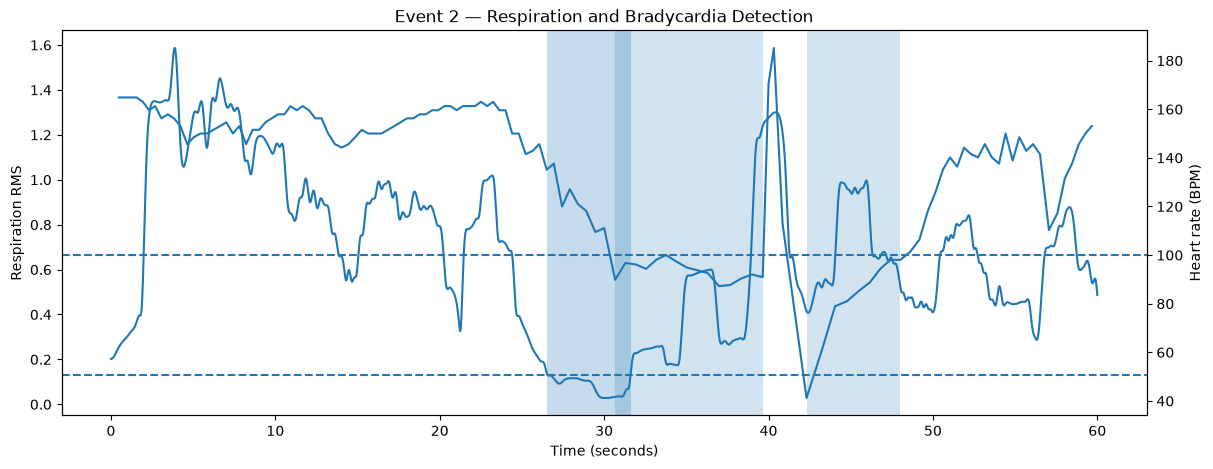

In [49]:
# Visualize respiration and bradycardia detections for Event 2

fig, ax1 = plt.subplots(figsize=(14, 5))

# Respiration RMS
resp_time_event2 = np.arange(len(respiration_rms_event2)) / RESP_FS

ax1.plot(
    resp_time_event2,
    respiration_rms_event2,
    label="Respiration RMS"
)

ax1.axhline(
    resp_threshold_event2,
    linestyle="--",
    label="Low-respiration threshold"
)

ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("Respiration RMS")

# Mark low-respiration periods
for _, row in resp_runs_event2.iterrows():
    ax1.axvspan(
        row["start"],
        row["end"],
        alpha=0.25,
        label="Low respiration"
    )

# Second axis for heart rate
ax2 = ax1.twinx()

ax2.plot(
    hr_times2,
    hr_event2,
    label="Heart rate"
)

ax2.axhline(
    100,
    linestyle="--",
    label="Bradycardia threshold"
)

# Mark bradycardia periods
for _, row in brady_runs_event2.iterrows():
    ax2.axvspan(
        row["start"],
        row["end"],
        alpha=0.20,
        label="Bradycardia"
    )

ax2.set_ylabel("Heart rate (BPM)")

ax1.set_title("Event 2 — Respiration and Bradycardia Detection")

plt.show()

In [50]:
# Calculate overlap between low-respiration periods
# and bradycardia periods

def calculate_overlap(resp_runs, brady_runs):
    """
    Calculate temporal overlap between respiration suppression
    and bradycardia runs.
    """

    overlaps = []

    for _, resp in resp_runs.iterrows():

        for _, brady in brady_runs.iterrows():

            overlap_start = max(
                resp["start"],
                brady["start"]
            )

            overlap_end = min(
                resp["end"],
                brady["end"]
            )

            overlap_duration = max(
                0.0,
                overlap_end - overlap_start
            )

            if overlap_duration > 0:

                overlaps.append([
                    resp["start"],
                    resp["end"],
                    brady["start"],
                    brady["end"],
                    overlap_start,
                    overlap_end,
                    overlap_duration
                ])

    return pd.DataFrame(
        overlaps,
        columns=[
            "resp_start",
            "resp_end",
            "brady_start",
            "brady_end",
            "overlap_start",
            "overlap_end",
            "overlap_duration"
        ]
    )


overlap_event2 = calculate_overlap(
    resp_runs_event2,
    brady_runs_event2
)

print("Respiration-bradycardia overlaps:")
print(overlap_event2.to_string(index=False))

Respiration-bradycardia overlaps:
 resp_start  resp_end  brady_start  brady_end  overlap_start  overlap_end  overlap_duration
     26.554    31.606       30.672     39.648         30.672       31.606             0.934


In [51]:
# Classify respiratory and bradycardia events

def classify_events(
    resp_runs,
    brady_runs,
    apnea_duration_threshold=20.0
):
    """
    Classify detected respiratory and bradycardia events.

    Categories:
        - apnea_candidate:
            respiratory pause >= 20 seconds
        - short_resp_with_brady:
            shorter respiratory suppression overlapping bradycardia
        - respiratory_suppression:
            short respiratory suppression without bradycardia
        - bradycardia_only:
            bradycardia without respiratory suppression
    """

    events = []

    # Process respiratory events
    for _, resp in resp_runs.iterrows():

        overlapping_brady = []

        for _, brady in brady_runs.iterrows():

            overlap_start = max(
                resp["start"],
                brady["start"]
            )

            overlap_end = min(
                resp["end"],
                brady["end"]
            )

            overlap_duration = max(
                0.0,
                overlap_end - overlap_start
            )

            if overlap_duration > 0:
                overlapping_brady.append({
                    "start": brady["start"],
                    "end": brady["end"],
                    "overlap": overlap_duration
                })

        if resp["duration"] >= apnea_duration_threshold:

            classification = "apnea_candidate"

        elif len(overlapping_brady) > 0:

            classification = "short_resp_with_brady"

        else:

            classification = "respiratory_suppression"

        events.append({
            "resp_start": resp["start"],
            "resp_end": resp["end"],
            "resp_duration": resp["duration"],
            "brady_overlap": len(overlapping_brady),
            "classification": classification
        })

    # Process bradycardia events that did not overlap respiration
    for _, brady in brady_runs.iterrows():

        has_overlap = False

        for _, resp in resp_runs.iterrows():

            overlap_start = max(
                resp["start"],
                brady["start"]
            )

            overlap_end = min(
                resp["end"],
                brady["end"]
            )

            if overlap_end > overlap_start:
                has_overlap = True
                break

        if not has_overlap:

            events.append({
                "resp_start": np.nan,
                "resp_end": np.nan,
                "resp_duration": np.nan,
                "brady_overlap": 0,
                "classification": "bradycardia_only"
            })

    return pd.DataFrame(events)


print("Event classification function created successfully.")

Event classification function created successfully.


In [52]:
# Test the event classifier on Event 2

classified_events_event2 = classify_events(
    resp_runs_event2,
    brady_runs_event2,
    apnea_duration_threshold=20.0
)

print("Event 2 classifications:")
print(classified_events_event2.to_string(index=False))

Event 2 classifications:
 resp_start  resp_end  resp_duration  brady_overlap        classification
     26.554    31.606          5.052              1 short_resp_with_brady
        NaN       NaN            NaN              0      bradycardia_only


In [53]:
# Respiration filter for apnea/pause detection
# Use a lower high-pass cutoff so long respiratory pauses are preserved.

RESP_LOW_APNEA = 0.03
RESP_HIGH_APNEA = 2.0
RESP_FILTER_ORDER = 4

sos_resp_apnea = butter(
    RESP_FILTER_ORDER,
    [RESP_LOW_APNEA, RESP_HIGH_APNEA],
    btype="band",
    fs=RESP_FS,
    output="sos"
)

respiration_apnea_filtered = sosfiltfilt(
    sos_resp_apnea,
    respiration
)

print("Apnea-oriented respiration filter created.")
print("Low cutoff:", RESP_LOW_APNEA, "Hz")
print("High cutoff:", RESP_HIGH_APNEA, "Hz")
print("Filtered signal range:",
      respiration_apnea_filtered.min(),
      "to",
      respiration_apnea_filtered.max())

Apnea-oriented respiration filter created.
Low cutoff: 0.03 Hz
High cutoff: 2.0 Hz
Filtered signal range: -0.4167226029490233 to 0.48667438721172457


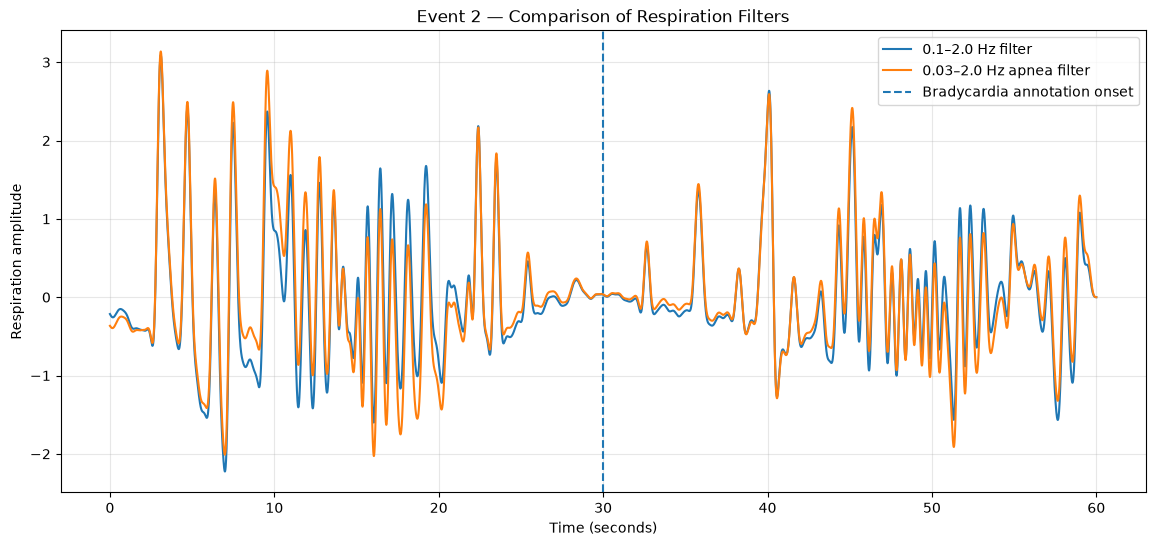

In [54]:
# Compare the two respiration filtering approaches on Event 2

# Apply the apnea-oriented filter to Event 2
resp_event2_apnea_filtered = sosfiltfilt(
    sos_resp_apnea,
    resp_event2
)

resp_time_event2 = np.arange(len(resp_event2)) / RESP_FS

plt.figure(figsize=(14, 6))

plt.plot(
    resp_time_event2,
    resp_event2_filtered,
    label="0.1–2.0 Hz filter"
)

plt.plot(
    resp_time_event2,
    resp_event2_apnea_filtered,
    label="0.03–2.0 Hz apnea filter"
)

plt.axvline(
    30,
    linestyle="--",
    label="Bradycardia annotation onset"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Respiration amplitude")
plt.title("Event 2 — Comparison of Respiration Filters")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [55]:
# Detect low-respiration periods using the apnea-oriented filter

resp_runs_event2_apnea, respiration_rms_event2_apnea, resp_threshold_event2_apnea = (
    detect_low_respiration_runs(
        resp_event2_apnea_filtered,
        fs=RESP_FS,
        threshold_factor=0.20,
        rms_window_seconds=2.0
    )
)

print("Event 2 low-respiration periods using apnea-oriented filter:")
print(resp_runs_event2_apnea.to_string(index=False))

print(
    "\nRespiration RMS threshold:",
    resp_threshold_event2_apnea
)

Event 2 low-respiration periods using apnea-oriented filter:
 start    end  duration
26.468 31.606     5.138
33.758 34.558     0.800

Respiration RMS threshold: 0.13588117114182374


In [56]:
# Classify Event 2 using the apnea-oriented respiration signal

classified_events_event2_apnea = classify_events(
    resp_runs_event2_apnea,
    brady_runs_event2,
    apnea_duration_threshold=20.0
)

print("Event 2 classifications using apnea-oriented respiration:")
print(
    classified_events_event2_apnea.to_string(index=False)
)

Event 2 classifications using apnea-oriented respiration:
 resp_start  resp_end  resp_duration  brady_overlap        classification
     26.468    31.606          5.138              1 short_resp_with_brady
     33.758    34.558          0.800              1 short_resp_with_brady
        NaN       NaN            NaN              0      bradycardia_only


In [57]:
# Minimum duration for a respiratory suppression to be considered
# for apnea-event classification

MIN_RESP_DURATION = 3.0  # seconds

resp_runs_event2_apnea_filtered_valid = resp_runs_event2_apnea[
    resp_runs_event2_apnea["duration"] >= MIN_RESP_DURATION
].reset_index(drop=True)

print("Minimum respiratory duration:", MIN_RESP_DURATION, "seconds")
print("\nRespiratory periods retained for event classification:")

if len(resp_runs_event2_apnea_filtered_valid) > 0:
    print(
        resp_runs_event2_apnea_filtered_valid.to_string(index=False)
    )
else:
    print("No respiratory periods meet the minimum duration.")

Minimum respiratory duration: 3.0 seconds

Respiratory periods retained for event classification:
 start    end  duration
26.468 31.606     5.138


In [58]:
# Cell 55 — Reclassify Event 2 using filtered respiratory periods

event2_classification_filtered = classify_events(
    resp_runs_event2_apnea_filtered_valid,
    brady_runs_event2
)

print("Event 2 classification after minimum-duration filtering:")
display(event2_classification_filtered)

Event 2 classification after minimum-duration filtering:


,resp_start,resp_end,resp_duration,brady_overlap,classification
0,26.468,31.606,5.138,1,short_resp_with_brady
1,NaN,NaN,NaN,0,bradycardia_only


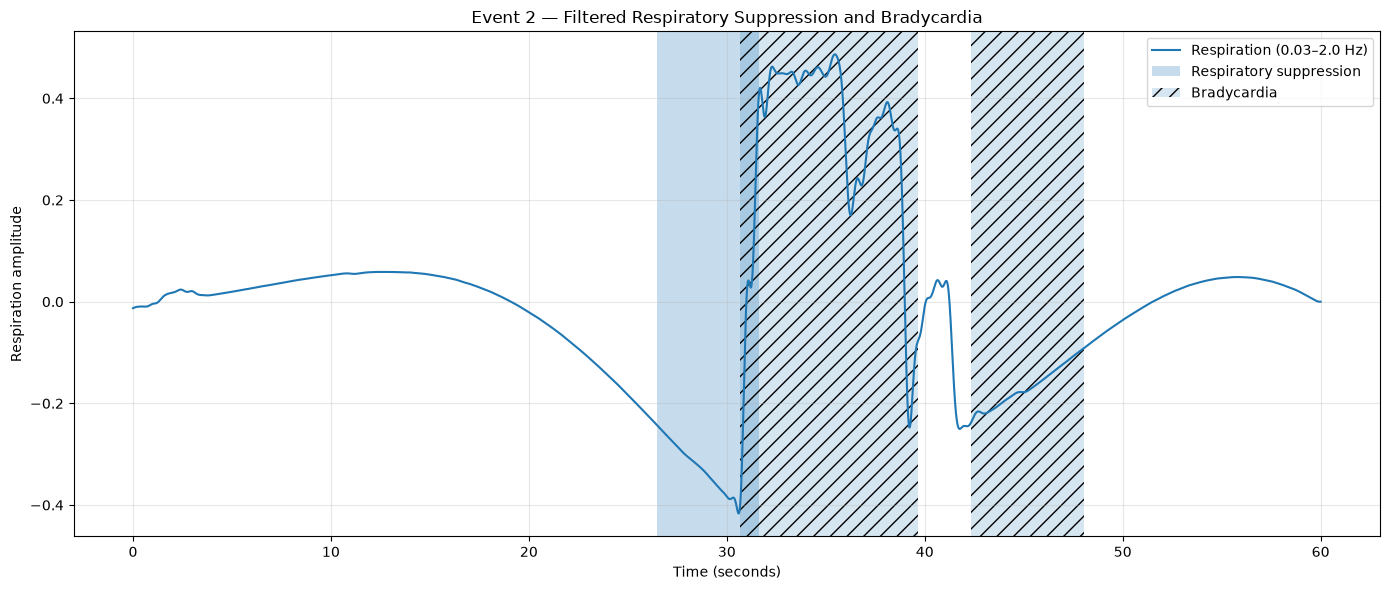

In [59]:
# Cell 56 — Visual validation of filtered Event 2 classification

# Create the respiration time axis for the 60-second Event 2 window
event2_time_resp = np.arange(len(respiration_apnea_filtered)) / RESP_FS

fig, ax = plt.subplots(figsize=(14, 6))

# Plot apnea-oriented filtered respiration
ax.plot(
    event2_time_resp,
    respiration_apnea_filtered,
    label="Respiration (0.03–2.0 Hz)"
)

# Mark retained respiratory suppression
for _, row in resp_runs_event2_apnea_filtered_valid.iterrows():
    ax.axvspan(
        row["start"],
        row["end"],
        alpha=0.25,
        label="Respiratory suppression"
    )

# Mark bradycardia runs
for _, row in brady_runs_event2.iterrows():
    ax.axvspan(
        row["start"],
        row["end"],
        alpha=0.18,
        hatch="//",
        label="Bradycardia"
    )

# Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))

ax.legend(
    unique.values(),
    unique.keys(),
    loc="upper right"
)

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Respiration amplitude")
ax.set_title(
    "Event 2 — Filtered Respiratory Suppression and Bradycardia"
)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
# Cell 57 — Event 2 validation summary

print("========== EVENT 2 VALIDATION SUMMARY ==========")

print("\nRespiratory periods retained:")
display(resp_runs_event2_apnea_filtered_valid)

print("\nBradycardia runs:")
display(brady_runs_event2)

print("\nFinal event classification:")
display(event2_classification_filtered)

# Basic validation checks
resp_durations = resp_runs_event2_apnea_filtered_valid["duration"]

print("\nValidation checks:")
print(
    "All retained respiratory periods >= 3 seconds:",
    bool((resp_durations >= MIN_RESP_DURATION).all())
)

print(
    "Number of retained respiratory periods:",
    len(resp_runs_event2_apnea_filtered_valid)
)

print(
    "Number of bradycardia runs:",
    len(brady_runs_event2)
)

print(
    "Number of classified events:",
    len(event2_classification_filtered)
)

print("\nEvent 2 validation checkpoint complete.")

========== EVENT 2 VALIDATION SUMMARY ==========

Respiratory periods retained:


,start,end,duration
0,26.468,31.606,5.138



Bradycardia runs:


,start,end,duration
0,30.672,39.648,8.976
1,42.312,48.024,5.712



Final event classification:


,resp_start,resp_end,resp_duration,brady_overlap,classification
0,26.468,31.606,5.138,1,short_resp_with_brady
1,NaN,NaN,NaN,0,bradycardia_only



Validation checks:
All retained respiratory periods >= 3 seconds: True
Number of retained respiratory periods: 1
Number of bradycardia runs: 2
Number of classified events: 2

Event 2 validation checkpoint complete.


In [61]:
# Cell 58 — Verify reusable event-analysis pipeline components

required_objects = [
    "detect_bradycardia_runs",
    "detect_low_respiration_runs",
    "calculate_overlap",
    "classify_events",
    "RESP_FS",
    "RESP_FILTER_ORDER",
    "RESP_LOW_APNEA",
    "RESP_HIGH_APNEA",
    "MIN_RESP_DURATION",
    "brady_times",
    "events_to_test"
]

print("========== PIPELINE READINESS CHECK ==========")

for name in required_objects:
    print(f"{name}: {'OK' if name in globals() else 'MISSING'}")

print("\nNumber of selected bradycardia events:", len(events_to_test))
print("Minimum respiratory duration:", MIN_RESP_DURATION, "seconds")
print("==============================================")

========== PIPELINE READINESS CHECK ==========
detect_bradycardia_runs: OK
detect_low_respiration_runs: OK
calculate_overlap: OK
classify_events: OK
RESP_FS: OK
RESP_FILTER_ORDER: OK
RESP_LOW_APNEA: OK
RESP_HIGH_APNEA: OK
MIN_RESP_DURATION: OK
brady_times: OK
events_to_test: OK

Number of selected bradycardia events: 10
Minimum respiratory duration: 3.0 seconds


In [63]:
# Cell 60 — Inspect Event 3 respiration detector output

print("Type of resp_runs_event3:", type(resp_runs_event3))

if isinstance(resp_runs_event3, tuple):
    print("Tuple length:", len(resp_runs_event3))
    
    for i, item in enumerate(resp_runs_event3):
        print(f"\nTuple item {i}:")
        print("Type:", type(item))
        
        if hasattr(item, "shape"):
            print("Shape:", item.shape)
        
        if hasattr(item, "columns"):
            print("Columns:", list(item.columns))
        
        print("Value:")
        print(item)
else:
    print("Object is not a tuple.")
    print(resp_runs_event3)

Type of resp_runs_event3: <class 'tuple'>
Tuple length: 3

Tuple item 0:
Type: <class 'pandas.DataFrame'>
Shape: (0, 3)
Columns: ['start', 'end', 'duration']
Value:
Empty DataFrame
Columns: [start, end, duration]
Index: []

Tuple item 1:
Type: <class 'numpy.ndarray'>
Shape: (30000,)
Value:
[2.04495979 2.04299582 2.04103625 ... 1.14666134 1.14773974 1.14882779]

Tuple item 2:
Type: <class 'numpy.float64'>
Shape: ()
Value:
0.22924821794187783


In [64]:
# Cell 61 — Correct Event 3 respiratory extraction and classification

# detect_low_respiration_runs() returns:
#   [0] detected respiratory periods
#   [1] moving RMS values
#   [2] RMS threshold

resp_runs_event3_detected = resp_runs_event3[0]
resp_rms_event3 = resp_runs_event3[1]
resp_threshold_event3 = resp_runs_event3[2]

# Apply the validated minimum-duration criterion
resp_runs_event3_valid = resp_runs_event3_detected[
    resp_runs_event3_detected["duration"] >= MIN_RESP_DURATION
].reset_index(drop=True)

print("========== EVENT 3 RESPIRATION VALIDATION ==========")
print("Respiratory periods detected:", len(resp_runs_event3_detected))
print("Minimum duration criterion:", MIN_RESP_DURATION, "seconds")
print("Respiratory periods retained:", len(resp_runs_event3_valid))

if len(resp_runs_event3_valid) > 0:
    display(resp_runs_event3_valid)
else:
    print("No respiratory suppression periods meet the minimum duration.")

print("\nRMS threshold:", resp_threshold_event3)

# -------------------------------------------------
# Event classification
# -------------------------------------------------

event3_classification = classify_events(
    resp_runs_event3_valid,
    brady_runs_event3
)

print("\n========== EVENT 3 CLASSIFICATION ==========")
display(event3_classification)

========== EVENT 3 RESPIRATION VALIDATION ==========
Respiratory periods detected: 0
Minimum duration criterion: 3.0 seconds
Respiratory periods retained: 0
No respiratory suppression periods meet the minimum duration.

RMS threshold: 0.22924821794187783

========== EVENT 3 CLASSIFICATION ==========


,resp_start,resp_end,resp_duration,brady_overlap,classification
0,NaN,NaN,NaN,0,bradycardia_only
1,NaN,NaN,NaN,0,bradycardia_only


In [65]:
# Event 4 — Automated ECG, respiration, and event analysis

EVENT_INDEX = 3
EVENT_TIME = events_to_test[EVENT_INDEX]

WINDOW_BEFORE = 30.0
WINDOW_AFTER = 30.0

window_start = EVENT_TIME - WINDOW_BEFORE
window_end = EVENT_TIME + WINDOW_AFTER

print("========== EVENT 4 AUTOMATED ANALYSIS ==========")
print(f"Bradycardia onset: {EVENT_TIME:.3f} s")
print(f"Analysis window: {window_start:.3f} to {window_end:.3f} s")

# -------------------------------------------------
# Load ECG and respiration
# -------------------------------------------------

ecg_event4_record = wfdb.rdrecord(
    "infant1_ecg",
    pn_dir="picsdb/1.0.0",
    sampfrom=int(window_start * ECG_FS),
    sampto=int(window_end * ECG_FS)
)

resp_event4_record = wfdb.rdrecord(
    "infant1_resp",
    pn_dir="picsdb/1.0.0",
    sampfrom=int(window_start * RESP_FS),
    sampto=int(window_end * RESP_FS)
)

ecg_event4 = ecg_event4_record.p_signal[:, 0]
resp_event4 = resp_event4_record.p_signal[:, 0]

print("\nLoaded signals:")
print("ECG samples:", len(ecg_event4))
print("ECG sampling frequency:", ecg_event4_record.fs)
print("Respiration samples:", len(resp_event4))
print("Respiration sampling frequency:", resp_event4_record.fs)

# -------------------------------------------------
# ECG R-peak detection and heart rate
# -------------------------------------------------

rpeaks_event4, _ = find_peaks(
    ecg_event4,
    distance=int(0.30 * ECG_FS),
    prominence=0.3
)

rpeak_times_event4 = rpeaks_event4 / ECG_FS

rr_event4 = np.diff(rpeak_times_event4)
hr_event4 = 60.0 / rr_event4
hr_times_event4 = rpeak_times_event4[1:]

print("\nECG analysis:")
print("Detected R peaks:", len(rpeaks_event4))
print("RR intervals:", len(rr_event4))
print(f"Mean HR: {np.mean(hr_event4):.2f} BPM")
print(f"Minimum HR: {np.min(hr_event4):.2f} BPM")
print(f"Maximum HR: {np.max(hr_event4):.2f} BPM")

# -------------------------------------------------
# Bradycardia detection
# -------------------------------------------------

brady_runs_event4 = detect_bradycardia_runs(
    hr_times_event4,
    hr_event4,
    threshold=100.0,
    minimum_duration=0.0
)

print("\nBradycardia runs:")
if len(brady_runs_event4) > 0:
    display(brady_runs_event4)
else:
    print("No bradycardia runs detected.")

# -------------------------------------------------
# Apnea-oriented respiration filter
# -------------------------------------------------

sos_resp_event4 = butter(
    RESP_FILTER_ORDER,
    [RESP_LOW_APNEA, RESP_HIGH_APNEA],
    btype="band",
    fs=RESP_FS,
    output="sos"
)

respiration_event4_apnea_filtered = sosfiltfilt(
    sos_resp_event4,
    resp_event4
)

# -------------------------------------------------
# Detect low-respiration periods
# -------------------------------------------------

resp_runs_event4 = detect_low_respiration_runs(
    respiration_event4_apnea_filtered,
    RESP_FS,
    threshold_factor=0.20,
    rms_window_seconds=2.0,
    minimum_duration=0.0
)

# The detector returns:
#   [0] respiratory-period DataFrame
#   [1] RMS values
#   [2] RMS threshold

resp_runs_event4_detected = resp_runs_event4[0]
resp_rms_event4 = resp_runs_event4[1]
resp_threshold_event4 = resp_runs_event4[2]

# Apply minimum 3-second criterion
resp_runs_event4_valid = resp_runs_event4_detected[
    resp_runs_event4_detected["duration"] >= MIN_RESP_DURATION
].reset_index(drop=True)

print("\nRespiration analysis:")
print("Respiratory periods detected:", len(resp_runs_event4_detected))
print("Minimum duration criterion:", MIN_RESP_DURATION, "seconds")
print("Respiratory periods retained:", len(resp_runs_event4_valid))
print("RMS threshold:", resp_threshold_event4)

if len(resp_runs_event4_valid) > 0:
    display(resp_runs_event4_valid)
else:
    print("No respiratory suppression periods meet the minimum duration.")

# -------------------------------------------------
# Event classification
# -------------------------------------------------

event4_classification = classify_events(
    resp_runs_event4_valid,
    brady_runs_event4
)

print("\n========== EVENT 4 CLASSIFICATION ==========")
display(event4_classification)

========== EVENT 4 AUTOMATED ANALYSIS ==========
Bradycardia onset: 4834.748 s
Analysis window: 4804.748 to 4864.748 s

Loaded signals:
ECG samples: 15000
ECG sampling frequency: 250
Respiration samples: 30000
Respiration sampling frequency: 500

ECG analysis:
Detected R peaks: 133
RR intervals: 132
Mean HR: 137.06 BPM
Minimum HR: 85.71 BPM
Maximum HR: 157.89 BPM

Bradycardia runs:


,start,end,duration
0,30.7,43.18,12.48



Respiration analysis:
Respiratory periods detected: 2
Minimum duration criterion: 3.0 seconds
Respiratory periods retained: 0
RMS threshold: 0.08433510724943111
No respiratory suppression periods meet the minimum duration.

========== EVENT 4 CLASSIFICATION ==========


,resp_start,resp_end,resp_duration,brady_overlap,classification
0,NaN,NaN,NaN,0,bradycardia_only


In [72]:
# Event 5 — Automated ECG, respiration, and event analysis

EVENT_INDEX = 4
EVENT_TIME = events_to_test[EVENT_INDEX]

WINDOW_BEFORE = 30.0
WINDOW_AFTER = 30.0

window_start = EVENT_TIME - WINDOW_BEFORE
window_end = EVENT_TIME + WINDOW_AFTER

print("========== EVENT 5 AUTOMATED ANALYSIS ==========")
print(f"Bradycardia onset: {EVENT_TIME:.3f} s")
print(f"Analysis window: {window_start:.3f} to {window_end:.3f} s")

# -------------------------------------------------
# Load ECG and respiration
# -------------------------------------------------

ecg_event5_record = wfdb.rdrecord(
    "infant1_ecg",
    pn_dir="picsdb/1.0.0",
    sampfrom=int(window_start * ECG_FS),
    sampto=int(window_end * ECG_FS)
)

resp_event5_record = wfdb.rdrecord(
    "infant1_resp",
    pn_dir="picsdb/1.0.0",
    sampfrom=int(window_start * RESP_FS),
    sampto=int(window_end * RESP_FS)
)

ecg_event5 = ecg_event5_record.p_signal[:, 0]
resp_event5 = resp_event5_record.p_signal[:, 0]

print("\nLoaded signals:")
print("ECG samples:", len(ecg_event5))
print("ECG sampling frequency:", ecg_event5_record.fs)
print("Respiration samples:", len(resp_event5))
print("Respiration sampling frequency:", resp_event5_record.fs)

# -------------------------------------------------
# ECG R-peak detection and heart rate
# -------------------------------------------------

rpeaks_event5, _ = find_peaks(
    ecg_event5,
    distance=int(0.30 * ECG_FS),
    prominence=0.3
)

rpeak_times_event5 = rpeaks_event5 / ECG_FS

rr_event5 = np.diff(rpeak_times_event5)
hr_event5 = 60.0 / rr_event5
hr_times_event5 = rpeak_times_event5[1:]

print("\nECG analysis:")
print("Detected R peaks:", len(rpeaks_event5))
print("RR intervals:", len(rr_event5))
print(f"Mean HR: {np.mean(hr_event5):.2f} BPM")
print(f"Minimum HR: {np.min(hr_event5):.2f} BPM")
print(f"Maximum HR: {np.max(hr_event5):.2f} BPM")

# -------------------------------------------------
# Bradycardia detection
# -------------------------------------------------

brady_runs_event5 = detect_bradycardia_runs(
    hr_times_event5,
    hr_event5,
    threshold=100.0,
    minimum_duration=0.0
)

print("\nBradycardia runs:")
if len(brady_runs_event5) > 0:
    display(brady_runs_event5)
else:
    print("No bradycardia runs detected.")

# -------------------------------------------------
# Apnea-oriented respiration filter
# -------------------------------------------------

sos_resp_event5 = butter(
    RESP_FILTER_ORDER,
    [RESP_LOW_APNEA, RESP_HIGH_APNEA],
    btype="band",
    fs=RESP_FS,
    output="sos"
)

respiration_event5_apnea_filtered = sosfiltfilt(
    sos_resp_event5,
    resp_event5
)

# -------------------------------------------------
# Detect low-respiration periods
# -------------------------------------------------

resp_runs_event5 = detect_low_respiration_runs(
    respiration_event5_apnea_filtered,
    RESP_FS,
    threshold_factor=0.20,
    rms_window_seconds=2.0,
    minimum_duration=0.0
)

resp_runs_event5_detected = resp_runs_event5[0]
resp_rms_event5 = resp_runs_event5[1]
resp_threshold_event5 = resp_runs_event5[2]

# Apply minimum 3-second criterion
resp_runs_event5_valid = resp_runs_event5_detected[
    resp_runs_event5_detected["duration"] >= MIN_RESP_DURATION
].reset_index(drop=True)

print("\nRespiration analysis:")
print("Respiratory periods detected:", len(resp_runs_event5_detected))
print("Minimum duration criterion:", MIN_RESP_DURATION, "seconds")
print("Respiratory periods retained:", len(resp_runs_event5_valid))
print("RMS threshold:", resp_threshold_event5)

if len(resp_runs_event5_valid) > 0:
    display(resp_runs_event5_valid)
else:
    print("No respiratory suppression periods meet the minimum duration.")

# -------------------------------------------------
# Event classification
# -------------------------------------------------

event5_classification = classify_events(
    resp_runs_event5_valid,
    brady_runs_event5
)

print("\n========== EVENT 5 CLASSIFICATION ==========")
display(event5_classification)

========== EVENT 5 AUTOMATED ANALYSIS ==========
Bradycardia onset: 7696.272 s
Analysis window: 7666.272 to 7726.272 s

Loaded signals:
ECG samples: 15000
ECG sampling frequency: 250
Respiration samples: 30000
Respiration sampling frequency: 500

ECG analysis:
Detected R peaks: 138
RR intervals: 137
Mean HR: 140.89 BPM
Minimum HR: 64.66 BPM
Maximum HR: 157.89 BPM

Bradycardia runs:


,start,end,duration
0,30.636,34.26,3.624



Respiration analysis:
Respiratory periods detected: 2
Minimum duration criterion: 3.0 seconds
Respiratory periods retained: 0
RMS threshold: 0.16514435306840233
No respiratory suppression periods meet the minimum duration.

========== EVENT 5 CLASSIFICATION ==========


,resp_start,resp_end,resp_duration,brady_overlap,classification
0,NaN,NaN,NaN,0,bradycardia_only


In [73]:
# Cell 66 — Automated ECG, respiration, and event analysis for Event 6

EVENT_NUMBER = 6
EVENT_TIME = events_to_test[EVENT_NUMBER - 1]

WINDOW_DURATION = 60.0
window_start = EVENT_TIME - WINDOW_DURATION / 2
window_end = EVENT_TIME + WINDOW_DURATION / 2

print("=" * 60)
print(f"EVENT {EVENT_NUMBER} AUTOMATED ANALYSIS")
print("=" * 60)

print(f"Bradycardia onset: {EVENT_TIME:.3f} s")
print(f"Analysis window: {window_start:.3f} to {window_end:.3f} s")

# Load ECG window
ecg_event_record = wfdb.rdrecord(
    "infant1_ecg",
    pn_dir="picsdb/1.0.0",
    sampfrom=int(window_start * ECG_FS),
    sampto=int(window_end * ECG_FS)
)

# Load respiration window
resp_event_record = wfdb.rdrecord(
    "infant1_resp",
    pn_dir="picsdb/1.0.0",
    sampfrom=int(window_start * RESP_FS),
    sampto=int(window_end * RESP_FS)
)

ecg_event = ecg_event_record.p_signal[:, 0]
resp_event = resp_event_record.p_signal[:, 0]

print("\nLoaded signals:")
print("ECG samples:", len(ecg_event))
print("ECG sampling frequency:", ecg_event_record.fs)
print("Respiration samples:", len(resp_event))
print("Respiration sampling frequency:", resp_event_record.fs)

EVENT 6 AUTOMATED ANALYSIS
Bradycardia onset: 8246.660 s
Analysis window: 8216.660 to 8276.660 s

Loaded signals:
ECG samples: 15000
ECG sampling frequency: 250
Respiration samples: 30000
Respiration sampling frequency: 500


In [74]:
# Cell 67 — ECG analysis for Event 6

# Detect R-peaks
peaks_event6, properties_event6 = find_peaks(
    ecg_event,
    distance=int(0.30 * ECG_FS),
    prominence=0.3
)

# Convert peak locations to absolute time
peak_times_event6 = (
    window_start + peaks_event6 / ECG_FS
)

# Calculate RR intervals
rr_intervals_event6 = np.diff(peak_times_event6)

# Calculate heart rate
hr_event6 = 60.0 / rr_intervals_event6
hr_times_event6 = peak_times_event6[1:]

print("ECG analysis:")
print("Detected R peaks:", len(peaks_event6))
print("RR intervals:", len(rr_intervals_event6))

if len(hr_event6) > 0:
    print(f"Mean HR: {np.mean(hr_event6):.2f} BPM")
    print(f"Minimum HR: {np.min(hr_event6):.2f} BPM")
    print(f"Maximum HR: {np.max(hr_event6):.2f} BPM")
else:
    print("No valid RR intervals detected.")

ECG analysis:
Detected R peaks: 142
RR intervals: 141
Mean HR: 148.14 BPM
Minimum HR: 82.42 BPM
Maximum HR: 174.42 BPM


In [75]:
# Cell 68 — Respiration analysis for Event 6

respiration_event6_apnea_filtered = sosfiltfilt(
    sos_resp_apnea,
    resp_event
)

resp_runs_event6 = detect_low_respiration_runs(
    respiration_event6_apnea_filtered,
    RESP_FS,
    threshold_factor=0.20,
    rms_window_seconds=2.0,
    minimum_duration=0.0
)

resp_runs_event6_valid = resp_runs_event6[
    resp_runs_event6["duration"] >= MIN_RESP_DURATION
].reset_index(drop=True)

print("Respiration analysis:")
print("Respiratory periods detected:", len(resp_runs_event6))
print("Minimum duration criterion:", MIN_RESP_DURATION, "seconds")
print("Respiratory periods retained:", len(resp_runs_event6_valid))

if len(resp_runs_event6_valid) > 0:
    print("\nRetained respiratory suppression periods:")
    display(resp_runs_event6_valid)
else:
    print("No respiratory suppression periods meet the minimum duration.")

# Calculate and display the RMS threshold used
_, _, rms_threshold_event6 = detect_low_respiration_runs(
    respiration_event6_apnea_filtered,
    RESP_FS,
    threshold_factor=0.20,
    rms_window_seconds=2.0,
    minimum_duration=0.0
)

print("RMS threshold:", rms_threshold_event6)

TypeError: tuple indices must be integers or slices, not str